In [1]:
import setuptools  # Ensures distutils is available
import pyximport
pyximport.install()
from scipy.integrate import trapezoid as trapz
import matplotlib.cm as cm
from datetime import datetime
import os
import shutil
import pandas as pd
#!/anaconda3/bin/python
from math import cos, sin, pi, sqrt
from numpy import (
    array, linspace, arange, loadtxt, vectorize, pi as npi, exp, zeros,
    empty, log, log2, finfo, true_divide, asarray, where, partition, isnan, nan,
    ones, argmax, argmin, set_printoptions, diagonal, round, inf,concatenate, sin, cos
    )
import imageio
from numpy.random import random
from scipy.integrate import trapezoid as trapz
from scipy.signal import correlate2d
from matplotlib import rcParams, rc, ticker, colors, cm
from matplotlib.style import use
from matplotlib.pyplot import subplots, close
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
from mpl_toolkits.axes_grid1 import make_axes_locatable
from os import getcwd
from datetime import datetime
import os
from matplotlib.patches import Rectangle
import matplotlib.font_manager as font_manager
import pyximport
import numpy as np
from matplotlib.ticker import ScalarFormatter
import matplotlib.colors as mcolors
from scipy.optimize import curve_fit, fsolve
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib
# Install setuptools to resolve the distutils issue
%pip install setuptools

import pyximport
pyximport.install()

from utilities import (
    calc_flux #, calc_learning_rate
    )
rc('font', **{'family': 'sans-serif', 'sans-serif': ['Helvetica']})
rc('text', usetex=True)


def infinite_eff(psi_0,psi_1,n0,n1,model):
    '''gets the psi_0/1 that is applied to model 1,3 
    (dont divide it for mod 2,4 before hand)'''
    
    if model=="model1":
        if abs(psi_0)>abs(psi_1):
            eff = - psi_1/psi_0
        else:
            eff = - psi_0/psi_1
    if model == "model2":
        if abs(n0*psi_0/8)>abs(n1*psi_1/3):
            eff = - (n1*psi_1/3)/(n0*psi_0/8)
        elif abs(n0*psi_0/8)==abs(n1*psi_1/3):
            eff =-1
        else:
            eff = - ((n0*psi_0/8)/(n1*psi_1/3))
    if model=="model3":
        X2 = (psi_0*((n1*psi_0/n0) + psi_1))
        X1 =(psi_1*(psi_0 + (n0*psi_1/n1)))
        if X2 != 0:
            if abs(psi_0/n0)>abs(psi_1/n1):
                eff = - X1/X2
            else:
                eff = - (X1/X2)**(-1)
        else:
            eff = 0
    if model == "model4":
        psi_0 = psi_0*n0/8
        psi_1 = psi_1*n1/3
        
        X2 = (psi_0*((n1*psi_0/n0) + psi_1))
        X1 =(psi_1*(psi_0 + (n0*psi_1/n1)))
        if X2 != 0:
            if abs(psi_0/n0)>abs(psi_1/n1):
                eff = - X1/X2
            else:
                eff = - (X1/X2)**(-1)
        else:
            eff = 0
            
        # eff = ["undefined" if x == -1 else x for x in eff]
    if model == "BFM" or model=="CS":
        eff = 0
    return eff

def set_params(model, n0,n1,f0,f1=-2.0,E0=2.0,E1=2.0):
    N = 100
    
     # energy scale of Fo
    Ecouple = 20.0 # energy scale of coupling between Fo and F1


    psi_0 = f0
    psi_1 = f1
    psi_0_n = f0
    psi_1_n = f1
    
    m0 = 1.0
    m1 = 1.0
    beta = 1.0
    gamma = 1000.0
    phase = 0.0
    
    if model =="model4" or model =="model2" or model=="BFM":
        psi_0_n = n0*psi_0/8
        psi_1_n = n1*psi_1/3
    
    if model=="CS":
        psi_0_n = n0*psi_0/8
        psi_1_n = -0.0
        psi_1 = -0.0
        gamma = 1500.0
    

    return (
        E0, Ecouple, E1,  psi_0, psi_1, psi_0_n, psi_1_n, 
        n0, n1,
        m0, m1, phase,beta, gamma, model
        ) 

DEPRECATION: Loading egg at /Users/sarealles/Desktop/Data/code/.venv/lib/python3.12/site-packages/Cython-3.1.0a0-py3.12-macosx-14.0-arm64.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330

[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
l_title_s = 10
l_entry_s = 8
ticks_size = 9
fs = 10
ts = 11
ms = 3
off_text_size = 9

In [84]:
def plot_P_vs_n0_and_vs_Ec_two_models(target_dir, model_array,n0_array_n0_change,Ec_curve_n0_change,Ec_array_Ec_change, n0_curve_Ec_change, n1,f0_array,f1_array,dt=0.001,N=1000,drag=1000):
    timescale = 1.5 * 10**4 
    '''timescale used in thesis'''
    timescale = 4.8 * 10**7 

    xlim= 15
    Ec_lim = 30
    #fig for P1  vs n0 (left), P1 vs Ec (right)
    fig, ax = plt.subplots(2, 2, figsize=(9,5),sharey="row",sharex="col")
    #fig1 for P1  vs n0
    fig1, ax1 = plt.subplots(1, 2, figsize=(8,2),sharey="row")
    #fig7 for P0  vs n0
    fig7, ax7 = plt.subplots(1, 2, figsize=(8,2),sharey="row")
    #fig3 for eta vs n0
    fig3, ax3 = plt.subplots(1, 2, figsize=(8,2),sharey="row")
    #fig6 for P1  vs Ec
    fig6, ax6 = plt.subplots(1, 2, figsize=(9,3),sharey="row")
    #fig8 for J_slip  vs n0
    fig8, ax8 = plt.subplots(1, 2, figsize=(9,3),sharey="row")
    #fig9 for J_0  vs n0
    fig9, ax9 = plt.subplots(1, 2, figsize=(9,3),sharey="row")
    #fig10 for J_1  vs n1
    fig10, ax10 = plt.subplots(1, 2, figsize=(9,3),sharey="row")

    ####Model plots######
    #model 1, fig4 for P1  vs n0, vs Ec
    fig4, ax4 = plt.subplots(1, 2, figsize=(9,3),sharey="row")
    #model 2, fig4 for P1  vs n0, vs Ec
    fig5, ax5 = plt.subplots(1, 2, figsize=(9,3),sharey="row")
    
    if "model1" in model_array and "model2" in model_array:
        fig4.suptitle(r"$\rm{spring-like \ coupling}, \ \rm{constant \ force}$", fontsize=fs)
        fig5.suptitle(r"$\rm{spring-like \ coupling}, \ \rm{scaling \ force}$", fontsize=fs)
    else:
        fig4.suptitle(r"$\rm{gear-like \ coupling}, \ \rm{constant \ force}$", fontsize=fs)
        fig5.suptitle(r"$\rm{gear-like \ coupling}, \ \rm{scaling \ force}$", fontsize=fs)
        ax3[0].set_title(r"$\rm{constant \ force}$", fontsize=fs)
        ax3[1].set_title(r"$\rm{scaling \ force}$", fontsize=fs)

    
    # ax[0,0].set_title(r"$\mathrm{constant \ force}$", fontsize=24)
    # ax[1,0].set_title(r"$\mathrm{scaling \ force}$", fontsize=24)
    # ax[0,1].set_title(r"$\mathrm{constant \ force}$", fontsize=24)
    # ax[1,1].set_title(r"$\mathrm{scaling \ force}$", fontsize=24)
    
    # ax1[0].set_title(r"$\mathrm{constant \ force}$", fontsize=24)
    # ax1[1].set_title(r"$\mathrm{scaling \ force}$", fontsize=24)
    # ax3[0].set_title(r"$\mathrm{constant \ force}$", fontsize=24)
    # ax3[1].set_title(r"$\mathrm{scaling \ force}$", fontsize=24)


    
    
    
    
    y=-1.0*(10**5)*np.ones(30)
    ax1[0].fill_between(linspace(0,30,30),y , where=(y < 0), color='red', alpha=0.05)
    ax1[1].fill_between(linspace(0,30,30),y , where=(y < 0), color='red', alpha=0.05)
    
    y=-0.2*(10**6)*np.ones(30)
    # ax7[0].fill_between(linspace(0,30,30),y , where=(y < 0), color='red', alpha=0.05)
    # ax7[1].fill_between(linspace(0,30,30),y , where=(y < 0), color='red', alpha=0.05)


    

    # ax1[1].fill_between(linspace(0,30,30),y , where=(y < 0), color='red', alpha=0.1)
    # ax1[0].fill_between(linspace(0,30,30),y , where=(y < 0), color='red', alpha=0.1)
    ############################
    y=-1.5*(10**5)*np.ones(200)
    # ax[0,1].fill_between(linspace(0,200,200),y , where=(y < 0), color='red', alpha=0.05)
    # ax[1,1].fill_between(linspace(0,200,200),y , where=(y < 0), color='red', alpha=0.05)
    # ax4[0].fill_between(linspace(0,200,200),y , where=(y < 0), color='red', alpha=0.05)
    # ax4[1].fill_between(linspace(0,200,200),y , where=(y < 0), color='red', alpha=0.05)
    # ax5[0].fill_between(linspace(0,200,200),y , where=(y < 0), color='red', alpha=0.05)
    # ax5[1].fill_between(linspace(0,200,200),y , where=(y < 0), color='red', alpha=0.05)

    ###########################
    y=-0.65*np.ones(len(n0_array_n0_change))
    # ax3[0].fill_between(n0_array_n0_change,y , where=(y < 0), color='red', alpha=0.05)
    # ax3[1].fill_between(n0_array_n0_change,y , where=(y < 0), color='red', alpha=0.05)
    
    ####setting axis limit for models' plots#####
    ax4[0].set_xlim(left=1, right=xlim)
    ax4[1].set_xlim(left=1,right=128)
    ax4[0].set_xticks([1, 2, 5, 10, 15])
    ax4[0].get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
    ax5[0].set_xlim(left=1, right=xlim)
    ax5[1].set_xlim(left=1,right=128)
    ax5[0].set_xticks([1, 2,5, 10, 15])
    ax5[0].get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())

    #########
    for i in range(2):
        '''P1 sepaarte'''
        ax1[i].axhline(0.0, color="black", lw=0.5)
        ax1[i].ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
        ax1[i].yaxis.offsetText.set_fontsize(off_text_size)
        ax1[i].spines['right'].set_visible(False)
        ax1[i].spines['bottom'].set_visible(False)
        ax1[i].spines['top'].set_visible(False)
        ax1[i].set_xscale("log")
        ax1[i].set_xlim(left=1, right=xlim)
        ax1[i].set_xticks([1, 2, 5, 10, 15])
        ax1[i].get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())

        ax7[i].axhline(0.0, color="black", lw=0.5)
        ax7[i].ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
        ax7[i].yaxis.offsetText.set_fontsize(off_text_size)
        ax7[i].spines['right'].set_visible(False)
        ax7[i].spines['bottom'].set_visible(False)
        ax7[i].spines['top'].set_visible(False)
        # ax7[i].set_xscale("log")
        # ax7[i].set_xlim(left=1, right=xlim)
        # ax7[i].set_xticks([1, 2, 5, 10, 15])
        ax7[i].get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
        '''eta separate'''
        ax3[i].axhline(0.0, color="black", lw=1.0)
        ax3[i].spines['right'].set_visible(False)
        ax3[i].spines['bottom'].set_visible(False)
        ax3[i].spines['top'].set_visible(False)
        ax3[i].set_xscale("log")
        ax3[i].set_xlim(left=1, right=xlim)
        ax3[i].set_xticks([1, 2,5, 10, 15])
        ax3[i].get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
        '''models separate'''
        ax4[i].axhline(0.0,color="black", lw=1.0)
        ax4[i].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
        ax4[i].yaxis.offsetText.set_fontsize(off_text_size) 
        ax4[i].axhline(0.0, color="black", lw=1.0)
        ax4[i].spines['right'].set_visible(False)
        ax4[i].spines['bottom'].set_visible(False)
        ax4[i].spines['top'].set_visible(False)
        ax4[i].set_xscale("log")

        #########
        ax5[i].axhline(0.0,color="black", lw=1.0)
        ax5[i].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
        ax5[i].yaxis.offsetText.set_fontsize(off_text_size) 
        ax5[i].axhline(0.0, color="black", lw=1.0)
        ax5[i].spines['right'].set_visible(False)
        ax5[i].spines['bottom'].set_visible(False)
        ax5[i].spines['top'].set_visible(False)
        ax5[i].set_xscale("log")

        ax8[i].axhline(0.0,color="black", lw=1.0)
        ax8[i].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
        ax8[i].yaxis.offsetText.set_fontsize(off_text_size) 
        ax8[i].axhline(0.0, color="black", lw=1.0)
        ax8[i].spines['right'].set_visible(False)
        ax8[i].spines['bottom'].set_visible(False)
        ax8[i].spines['top'].set_visible(False)
        ax8[i].set_xscale("log")

        for j in range(2):
            ax[i,j].axhline(0.0,color="black", lw=1.0)
            ax[i,j].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
            ax[i, j].yaxis.offsetText.set_fontsize(off_text_size) 
            ax[i,j].spines['right'].set_visible(False)
            ax[i,j].spines['bottom'].set_visible(False)
            ax[i,j].spines['top'].set_visible(False)
            ax[i,j].set_xscale("log")
            ax[i,0].set_xlim(left=1,right=xlim)
            ax[0,j].set_xlim(left=1,right=Ec_lim)
            ax[i,0].set_xticks([1, 2,5, 10,15])
            ax[i,j].get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
            
            
            

            

            
            
    '''second column'''
    for ii,model in enumerate(model_array[2:]):
        print("start second column")
        input_file_name = (
            "/" + model + "_flux_power_efficiency_"
            + "E0_{0}_E1_{1}_psi0_{2}_psi1_{3}_n0_{4}_n1_{5}_phase_{6}_outfile.dat"
            )
        if model == "model1" or model == "model2":
            colors = cm.RdPu(np.linspace(0.5, 1, len(n0_curve_Ec_change)))
        else:
            colors = cm.YlGn(np.linspace(0.5, 1, len(n0_curve_Ec_change)))
            

        for h, (n0, color) in enumerate(zip(n0_curve_Ec_change, colors)):
            print(f"h is {h}, n0 is {n0}, color is {color}")
            [
            E0, __,E1, psi_0, psi_1,psi_0_n, psi_1_n, __, __,
            m0, m1, phase,beta, gamma,__
            ] = set_params(model, n0, n1, f0_array[ii+2], E0=2.0, E1=2.0)
            print(f"for model {model}, gamma is {gamma}, psi_0 is {psi_0}, psi_1 is {psi_1}")
            n0n1_str = str(int(n0)) + "_" + str(int(n1))
            target = target_dir[ii+2]
            try:
                Ecouple_array, integrate_flux_X, integrate_flux_Y, integrate_power_X, integrate_power_Y, efficiency, efficiency_mod = loadtxt(
                target + n0n1_str + input_file_name.format(E0, E1, psi_0, psi_1, n0, n1, phase), unpack=True, usecols=(0, 1, 2, 3, 4, 5, 6))
            except:
                print(f"no file for {model}, n0={n0}, n1={n1}")
                continue
            print("loaded data for ", model, n0, n1)
            if model in ["BFM", "CS"]:
                print("BFM or CS")
                ax[ii, 1].plot(
                Ecouple_array, 2*pi*gamma * timescale*(integrate_flux_Y**2), marker="o", lw=1.0, markersize=ms,
                label="${0}$".format(int(n0)), color=color
                )
                if ii == 0:
                    ax4[1].plot(
                    Ecouple_array, 2*pi*gamma * timescale*(integrate_flux_Y**2), marker="o", lw=1.0, markersize=ms,
                    label="${0}$".format(int(n0)), color=color
                    )
                else:
                    ax5[1].plot(
                    Ecouple_array, 2*pi*gamma * timescale*(integrate_flux_Y**2), marker="o", lw=1.0, markersize=ms,
                    label="${0}$".format(int(n0)), color=color
                    )
            
            else:
                print("not BFM or CS, model is ", model)
                if 0.0 in Ecouple_array:
                    zero_index = np.where(Ecouple_array == 0.0)[0][0]
                    Ecouple_array = np.delete(Ecouple_array, zero_index)
                    integrate_power_Y = np.delete(integrate_power_Y, zero_index)
                
                
                
                ax[ii, 1].plot(
                Ecouple_array, -2 * pi * timescale*integrate_power_Y, marker="o", lw=1.0, markersize=ms,
                label="${0}$".format(int(n0)), color=color, zorder=-h
                )
                if ii == 0:
                    ax4[1].plot(
                    Ecouple_array, -2 * pi * timescale*integrate_power_Y, marker="o", lw=1.0, markersize=ms,
                    label="${0}$".format(int(n0)), color=color
                    )
                else:
                    ax5[1].plot(
                    Ecouple_array, -2 * pi * timescale*integrate_power_Y, marker="o", lw=1.0, markersize=ms,
                    label="${0}$".format(int(n0)), color=color
                    )

                
                
    
    
    ####################################################
    '''first column'''
    Ecouple= []
    maximizing_n0 = []
    index = -1
    for jj,model in enumerate(model_array[:2]):
        
        index +=1
        f0 = f0_array[jj]
        f1 = f1_array[jj]
        if model == "model1" or model == "model2":
            colors = cm.PuBuGn(np.linspace(0.4, 1, len(Ec_curve_n0_change)))[::-1]
        else:
            colors = cm.YlOrBr(np.linspace(0.4, 1, len(Ec_curve_n0_change)))[::-1]
        colors1 = cm.gist_earth(np.linspace(0, 0.8, len(Ec_curve_n0_change)))[::-1]
        colors1 = cm.YlOrBr(np.linspace(0.4, 1, len(Ec_curve_n0_change)))[::-1]
        for i,Ec in enumerate(Ec_curve_n0_change):
            n0_exists = []
            P_at_Ec = []
            P0_at_Ec = []
            eta_at_Ec = []
            eta_at_inf = []
            eta_Fo_wins = []
            j1_at_Ec = []
            jo_at_Ec = []
            jslip_at_Ec = []
            
            for n0 in n0_array_n0_change:
                n0n1_str = str(int(n0))+"_"+ str(int(n1))
                '''uncomment the following line and comment the lines after for model1,2'''

                target_dir_temp = target_dir[jj] + n0n1_str
                #     print(target_dir_temp)
                    
                if not os.path.exists(target_dir_temp):
                    print(target_dir_temp)
            
                [
                E0, __,E1, psi_0, psi_1,psi_0_n, psi_1_n, __, __,
                m0, m1, phase,beta, gamma,__
                ] = set_params(model, n0, n1, f0_array[jj], E0=2.0, E1=2.0)

                input_file_name = ("/" + model + "_flux_power_efficiency_"
                + "E0_{0}_E1_{1}_psi0_{2}_psi1_{3}_n0_{4}_n1_{5}_phase_{6}_outfile.dat")
                
                if not os.path.exists(target_dir_temp + input_file_name.format(E0, E1, psi_0, psi_1, n0, n1, phase,dt,N)):
                    continue

                Ec_list,integrate_flux_X, integrate_flux_Y,integrate_power_X, integrate_power_Y, efficiency,efficiency_mod= loadtxt(
                target_dir_temp + input_file_name.format(E0,E1, psi_0, psi_1, n0,n1,phase,dt,N),unpack=True, usecols=(0,1,2,3,4,5,6))

                # Convert Ec_list to a list if it is a single value
                if isinstance(Ec_list, float):
                    Ec_list = [Ec_list]
                    integrate_power_Y = [integrate_power_Y]
                    integrate_power_X = [integrate_power_X]
                    integrate_flux_X = [integrate_flux_X]
                    integrate_flux_Y = [integrate_flux_Y]
                    efficiency_mod = [efficiency_mod]
                    efficiency = [efficiency]

                # print(integrate_power_Y)
                for j in range(len(Ec_list)):
                    if Ec_list[j] == Ec:
                        j1_at_Ec.append(integrate_flux_Y[j])
                        jo_at_Ec.append(integrate_flux_X[j])
                        eta_Fo_wins.append(efficiency[j])
                        n0_exists.append(int(n0))
                        P0_at_Ec.append(2*pi*integrate_power_X[j])


                        if model in ["BFM", "CS"] and f1==-0.0:
                            P_at_Ec.append(2*pi*gamma*((j1_at_Ec[-1])**2))
                            # eta_at_Ec.append(P_at_Ec[-1]/P0_at_Ec[-1])
                        else:
                            P_at_Ec.append(-2*pi*integrate_power_Y[j])
                            # eta_at_Ec.append(efficiency_mod[j])
                            # eta_at_Ec.append(P_at_Ec[-1]/P0_at_Ec[-1])

                        if abs(P_at_Ec[-1])> abs(P0_at_Ec[-1]):
                            eta_at_Ec.append(P0_at_Ec[-1]/P_at_Ec[-1])
                            # print(f"model = {model}, Ec= {Ec}, n0={n0}, F1 is upstream")
                            print(f"model = {model}, Ec= {Ec}, n0={n0}, P0 is {P0_at_Ec[-1]}, P1 is {P_at_Ec[-1]}, F1 is upstream")

                        else:
                            eta_at_Ec.append(P_at_Ec[-1]/P0_at_Ec[-1])
                            print(f"model = {model}, Ec= {Ec}, n0={n0}, P0 is {P0_at_Ec[-1]}, P1 is {P_at_Ec[-1]}, F0 is upstream")

                        if model =="model3" or model=="model4" or model=="BFM" or model=="CS":
                            jslip_at_Ec.append(n0*integrate_flux_X[j]-n1*integrate_flux_Y[j])
                        else:
                            jslip_at_Ec.append(integrate_flux_X[j]-integrate_flux_Y[j])
                            
                        
                eta_at_inf.append(infinite_eff(psi_0,psi_1,n0,n1,model))
                # if model =="model4":
                #     print(f"for model {model}, n0 is {n0}, eta at inf is {eta_at_inf[-1]}")
            # print(f"for model {model}, len eta at inf is {len(eta_at_inf)}")

            if len(n0_exists)!=0:
                Ecouple.append(Ec)
                maximizing_n0.append(n0_exists[argmax(j1_at_Ec)])
            # print(fr"at {int(Ec)}, n0 that maximizes J1 is: {n0_exists[argmax(j1_at_Ec)]}")
            '''efficiency separate fig'''
            if model == "model1":
                ax3[jj].scatter(n0_array_n0_change,eta_at_inf, marker="s",alpha = 0.08, s=70, color='purple') 
                n0_exists_no_stall = n0_exists 
                eta_at_Ec_no_stall = eta_at_Ec
            elif model =="model2":
                eta_at_inf[3]=np.nan                    
                ax3[jj].scatter(n0_array_n0_change,eta_at_inf, marker="s",alpha = 0.08, s=70, color='purple')  
                n0_exists_no_stall = []
                eta_at_Ec_no_stall = []
                stall_point = int(-8*f1/f0)
                print("stall point is ", stall_point)
                for ii,n0 in enumerate(n0_exists):
                    if int(n0) != stall_point:
                        eta_at_Ec_no_stall.append(eta_at_Ec[ii])
                        n0_exists_no_stall.append(n0)
                    else:
                        eta_at_Ec_no_stall.append(nan)
                        n0_exists_no_stall.append(nan)
                        
                eta_at_Ec_no_stall = array(eta_at_Ec_no_stall)
                n0_exists_no_stall = array(n0_exists_no_stall)
            elif model =="model3":
                eta_at_inf[11]=np.nan                    
                ax3[jj].scatter(n0_array_n0_change,eta_at_inf, marker="s",alpha = 0.08, s=70, color='purple')
                n0_exists_no_stall = []
                eta_at_Ec_no_stall = []
                stall_point = int(-f0*n1/f1)
                for ii,n0 in enumerate(n0_exists):
                    if int(n0) != stall_point or Ec <= 10.0:
                        eta_at_Ec_no_stall.append(eta_at_Ec[ii])
                        n0_exists_no_stall.append(n0)
                    elif int(n0) == stall_point and Ec >= 10.0:
                        eta_at_Ec_no_stall.append(nan)
                        n0_exists_no_stall.append(nan)
                eta_at_Ec_no_stall = array(eta_at_Ec_no_stall)
                n0_exists_no_stall = array(n0_exists_no_stall)
            else:
                print("eta at inf is ", len(eta_at_inf))
                print("n0 array is ", len(n0_array_n0_change))
                ax3[jj].scatter(n0_array_n0_change,(-(f1/3)/(f0/8))*ones(len(n0_array_n0_change)), marker="s",alpha = 0.08, s=70, color='purple')
                n0_exists_no_stall = n0_exists
                eta_at_Ec_no_stall = eta_at_Ec
            if len(eta_at_Ec)>0:
                print(f"for model {model}, Ec={Ec}, n0_esist_no_stall are {n0_exists_no_stall}, eta_at_Ec are {eta_at_Ec}")
                ax3[jj].plot(n0_exists_no_stall,eta_at_Ec_no_stall, label = fr"${int(Ec)}$",marker ="o", color=colors[i],lw=1.0,markersize=ms)
            ax3[jj].tick_params(labelsize=ts, axis='both')
            ax3[jj].set_xlabel(r"$\# \ \mathrm{subunits \ on} \ \rm{F}_{\rm o} \ (n_{\rm o})$", fontsize=fs)
            
            #################
            ax8[index].plot(n0_exists, timescale*array(jslip_at_Ec), label = fr"${int(Ec)}$",marker ="o", color=colors[i],lw=1.0,markersize=ms)
            ax9[index].plot(n0_exists, timescale*array(jo_at_Ec), label = fr"${int(Ec)}$",marker ="o", color=colors[i],lw=1.0,markersize=ms)
            ax10[index].plot(n0_exists, timescale*array(j1_at_Ec), label = fr"${int(Ec)}$",marker ="o", color=colors[i],lw=1.0,markersize=ms)
            ax8[index].tick_params(labelsize=ts, axis='both')
            ax9[index].tick_params(labelsize=ts, axis='both')
            ax10[index].tick_params(labelsize=ts, axis='both')
            ax8[index].set_xticks(n0_exists)
            ax9[index].set_xticks(n0_exists)
            ax10[index].set_xticks(n0_exists)
            ax[index,0].plot(n0_exists,timescale*array(P_at_Ec), label = fr"${int(Ec)}$",marker ="o", color=colors[i],lw=1.0,markersize=ms, zorder=-i)
            if jj == 0:
                ax4[0].plot(n0_exists,timescale*array(P_at_Ec), label = fr"${int(Ec)}$",marker ="o", color=colors[i],lw=1.0,markersize=ms)
            else:
                ax5[0].plot(n0_exists,timescale*array(P_at_Ec), label = fr"${int(Ec)}$",marker ="o", color=colors[i],lw=1.0,markersize=ms)

            ax[index,0].tick_params(labelsize=ts, axis='both')
            ax[index,1].tick_params(labelsize=ts, axis='both')
            ax4[index].tick_params(labelsize=ts, axis='both')
            ax5[index].tick_params(labelsize=ts, axis='both')
            
            ax[index,0].set_xticks(n0_exists)
            # ax4[0].set_xticks(n0_exists)
            # ax5[0].set_xticks(n0_exists)
            ax[index,0].set_ylabel(r"$\mathrm{output \ power} \ \beta \mathcal{P}_{1} \ (\rm{s}^{-1})$", fontsize=fs)
            ax4[0].set_ylabel(r"$\mathrm{output \ power} \ \beta \mathcal{P}_{1} \ (\rm{s}^{-1})$", fontsize=fs)
            ax5[0].set_ylabel(r"$\mathrm{output \ power} \ \beta \mathcal{P}_{1} \ (\rm{s}^{-1})$", fontsize=fs)
            
            
            '''separate fig'''
            ax1[jj].plot(n0_exists,timescale*array(P_at_Ec), label = fr"${int(Ec)}$",marker ="o", color=colors[i],lw=1.0,markersize=ms, zorder=-i)
            ax1[jj].tick_params(labelsize=ts, axis='both')
            ax1[jj].tick_params(labelsize=ts, axis='both')
            ax1[jj].set_xticks(n0_exists)
            ax1[0].set_ylabel(r"$\mathrm{output \ power} \ \beta \mathcal{P}_{1} \ (\rm{s}^{-1})$", fontsize=fs)
            
            ax7[jj].plot(n0_exists,timescale*array(P0_at_Ec), label = fr"${int(Ec)}$",marker ="o", color=colors[i],lw=1.0,markersize=ms,zorder=-i)
            ax7[jj].tick_params(labelsize=ts, axis='both')
            ax7[jj].tick_params(labelsize=ts, axis='both')
            ax7[jj].set_xticks(n0_exists)
            ax7[0].set_ylabel(r"$\mathrm{input \ power} \ \beta \mathcal{P}_{\rm{o}} \ (\rm{s}^{-1})$", fontsize=fs)
            
            ax8[jj].tick_params(labelsize=ts, axis='both')
            ax8[jj].tick_params(labelsize=ts, axis='both')
            ax8[jj].set_xticks(n0_exists)
            ax8[0].set_ylabel(r"$\mathrm{slippage} \ \mathcal{J}_{\rm{slip}} \ (\rm{s}^{-1})$", fontsize=fs)

                    

                    
    '''separate fig'''
    ax3[0].set_ylabel(r"$\mathrm{efficiency} \ \eta$", fontsize=fs)
    ax3[0].legend(prop={'size': l_entry_s}, title=r'$\beta E_{\rm c}$', title_fontsize=l_title_s, frameon=False, ncol=1, labelspacing=0.3, loc='best')


    
    ax1[1].set_xlabel(r"$\# \ \mathrm{subunits \ on} \ \rm{F}_{\rm o} \ (n_{\rm o})$", fontsize=fs)
    ax1[0].set_xlabel(r"$\# \ \mathrm{subunits \ on} \ \rm{F}_{\rm o} \ (n_{\rm o})$", fontsize=fs)
    ax1[1].set_xticks(n0_exists)
    ax1[1].set_xticks([1,2,5,10,15])
    ax1[0].set_xticks(n0_exists)
    ax1[0].set_xticks([1,2,5,10,15])
    ax1[1].get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
    ax1[0].get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
    ax1[0].legend(prop={'size': l_entry_s}, title=r'$\beta E_{\rm c}$', title_fontsize=l_title_s, frameon=False, ncol=1, labelspacing=0.3, loc='best')
    
    ax8[1].set_xlabel(r"$\# \ \mathrm{subunits \ on} \ \rm{F}_{\rm o} \ (n_{\rm o})$", fontsize=fs)
    ax8[0].set_xlabel(r"$\# \ \mathrm{subunits \ on} \ \rm{F}_{\rm o} \ (n_{\rm o})$", fontsize=fs)
    ax8[1].set_xticks(n0_exists)
    ax8[1].set_xticks([1,2,5,10,15])
    ax8[0].set_xticks(n0_exists)
    ax8[0].set_xticks([1,2,5,10,15])
    ax8[0].set_xlim(left=1, right=xlim)
    ax8[1].set_xlim(left=1, right=xlim)
    ax8[1].get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
    ax8[0].get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
    ax8[0].legend(prop={'size': l_entry_s}, title=r'$\beta E_{\rm c}$', title_fontsize=l_title_s, frameon=False, ncol=1, labelspacing=0.3, loc='best')
    ax8[0].vlines(3, 0, 1.5*(10**4), colors='grey', linestyles='solid', lw=1.0, alpha=1, zorder=-1000)
    ax8[1].vlines(3, 0, 1.5*(10**4), colors='grey', linestyles='solid', lw=1.0, alpha=1, zorder=-1000)


    ax7[1].set_xlabel(r"$\# \ \mathrm{subunits \ on} \ \rm{F}_{\rm o} \ (n_{\rm o})$", fontsize=fs)
    ax7[0].set_xlabel(r"$\# \ \mathrm{subunits \ on} \ \rm{F}_{\rm o} \ (n_{\rm o})$", fontsize=fs)
    ax7[1].set_xticks(n0_exists)
    ax7[1].set_xticks([1,2,3,4])
    ax7[0].set_xticks(n0_exists)
    ax7[0].set_xticks([1,2,3,4])
    ax7[1].set_xlim(left=1, right=4)
    ax7[1].get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
    ax7[0].get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
    ax7[0].legend(prop={'size': l_entry_s}, title=r'$\beta E_{\rm c}$', title_fontsize=l_title_s, frameon=False, ncol=1, labelspacing=0.3, loc='best')


    '''models'''
    ax4[0].set_xlabel(r"$\# \ \mathrm{subunits \ on} \ \rm{F}_{\rm o} \ (n_{\rm o})$", fontsize=fs)
    ax4[1].set_xlabel(r"$\beta E_{\rm c}$", fontsize=fs)
    ax4[0].set_xticks(n0_exists)
    ax4[0].set_xticks([1,2,5,10,int(n0_array_n0_change[-1])])
    ax4[0].get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
    ax4[1].set_xticks([1,10,Ec_lim])
    ax4[1].get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
    ax4[0].legend(prop={'size': l_entry_s}, title=r'$\beta E_{\rm c}$', title_fontsize=l_title_s, frameon=False, ncol=1, labelspacing=0.3, loc='best')
    ax4[1].legend(prop={'size': l_entry_s}, title=r'$n_{\rm o}$', title_fontsize=l_title_s, frameon=False, ncol=1, labelspacing=0.25, loc='best')
    
    ax5[0].set_xlabel(r"$\# \ \mathrm{subunits \ on} \ \rm{F}_{\rm o} \ (n_{\rm o})$", fontsize=fs)
    ax5[1].set_xlabel(r"$\beta E_{\rm c}$", fontsize=fs)
    ax5[0].set_xticks(n0_exists)
    ax5[0].set_xticks([1,2,5,10,int(n0_array_n0_change[-1])])
    ax5[0].get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
    ax5[1].set_xticks([1,10,Ec_lim])
    ax5[1].get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
    ax5[0].legend(prop={'size': l_entry_s}, title=r'$\beta E_{\rm c}$', title_fontsize=l_title_s, frameon=False, ncol=1, labelspacing=0.3, loc='best')
    ax5[1].legend(prop={'size': l_entry_s}, title=r'$n_{\rm o}$', title_fontsize=l_title_s, frameon=False, ncol=1, labelspacing=0.25, loc='best')

    ###################
    ax[1,0].set_xlabel(r"$\# \ \mathrm{subunits \ on} \ \rm{F}_{\rm o} \ (n_{\rm o})$", fontsize=fs)
    ax[1,1].set_xlabel(r"$\beta E_{\rm c}$", fontsize=fs)
    ax[1,0].set_xticks(n0_exists)
    ax[1,0].set_xticks([1,2,5,10,15])
    ax[1,1].set_xticks([1,10,Ec_lim])
    ax[1,0].get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
    ax[1,0].legend(prop={'size': l_entry_s}, title=r'$\beta E_{\rm c}$', title_fontsize=l_title_s, frameon=False, ncol=1, labelspacing=0.25, loc='best')
    ax[1,1].legend(prop={'size': l_entry_s}, title=r'$n_{\rm o}$', title_fontsize=l_title_s, frameon=False, ncol=1, labelspacing=0.25, loc='best')

    
    # ax[0,1].set_xlim(left=0, right=100)
            
    # ax1[0].set_ylim(top=0.4*(10**5))
    # ax7[0].set_ylim(top=2*(10**6))
    
    # y=-1.2*(10**5)*np.ones(30)
    # ax[1,0].fill_between(linspace(0,30,30),y , where=(y < 0), color='red', alpha=0.05)
    
    # y=-1.2*(10**5)*np.ones(200)
    # ax[1,1].fill_between(linspace(0,200,200),y , where=(y < 0), color='red', alpha=0.05)
    
    # y=-1.3*(10**5)*np.ones(30)
    # ax[0,0].fill_between(linspace(0,30,30),y , where=(y < 0), color='red', alpha=0.05)
    
    # y=-1.3*(10**5)*np.ones(200)
    # ax[0,1].fill_between(linspace(0,200,200),y , where=(y < 0), color='red', alpha=0.05)
    
    
    
    
    # ax[1,0].set_ylim(bottom=-1.25*(10**5))
    # ax[0,0].set_ylim(bottom=-1.5*(10**5))
    ax[0,0].vlines(3, -1.3*(10**5), 2.7*(10**5), colors='grey', linestyles='solid', lw=1.0, alpha=1, zorder=-1000)
    ax[1,0].vlines(3, 0, 9*(10**4), colors='grey', linestyles='solid', lw=1.0, alpha=1, zorder=-1000)

    # ax1[0].vlines(3, -1.0*(10**5), 2.5*(10**5), colors='grey', linestyles='solid', lw=1.0, alpha=1, zorder=-1000)
    # ax7[0].vlines(3, -2.0*(10**5), 5*(10**6), colors='grey', linestyles='solid', lw=1.0, alpha=1, zorder=-1000)
    #######################
    
    y=-1*np.ones(len(n0_array_n0_change))
    ax3[0].fill_between(n0_array_n0_change,y , where=(y < 0), color='red', alpha=0.05)
    ax3[1].fill_between(n0_array_n0_change,y , where=(y < 0), color='red', alpha=0.05)
    #####################
    y = -0.5*10**4*np.ones(len(n0_array_n0_change))
    ax7[1].fill_between(n0_array_n0_change,y , where=(y < 0), color='red', alpha=0.05)
    ax7[0].set_ylim(top=2.0*(10**4), bottom=-1*(10**4))
    # fig.savefig(fr"/Users/sarealles/Desktop/research/Thesis_plots/model3_4_P1_vs_n0_vs_Ec_n1_{n1}_fo_8.pdf",bbox_inches='tight')
    # fig4.savefig(fr"/Users/sarealles/Desktop/research/Thesis_plots/model3_P1_vs_n0_vs_Ec_n1_{n1}_fo_8.pdf",bbox_inches='tight')
    # fig5.savefig(fr"/Users/sarealles/Desktop/research/Thesis_plots/model4_P1_vs_n0_vs_Ec_n1_{n1}_fo_8.pdf",bbox_inches='tight')

    # fig3.savefig(fr"/Users/sarealles/Desktop/research/Thesis_plots/model3_4_eta_vs_n0_n1_{n1}_fo_8.pdf",bbox_inches='tight')

    fig1.savefig(fr"/Users/sarealles/Desktop/research/defense/model1_2_P1_vs_n0_n1_{n1}_fo_4.pdf",bbox_inches='tight')
    fig7.savefig(fr"/Users/sarealles/Desktop/research/defense/model1_2_P0_vs_n0_n1_{n1}_fo_4.pdf",bbox_inches='tight')
    plt.show()

start second column
h is 0, n0 is 1.0, color is [0.96702807 0.40464437 0.6307574  1.        ]
for model model1, gamma is 1000.0, psi_0 is 4.0, psi_1 is -2.0
loaded data for  model1 1.0 3.0
not BFM or CS, model is  model1
h is 1, n0 is 2.0, color is [0.86305267 0.2        0.59023453 1.        ]
for model model1, gamma is 1000.0, psi_0 is 4.0, psi_1 is -2.0
loaded data for  model1 2.0 3.0
not BFM or CS, model is  model1
h is 2, n0 is 3.0, color is [0.67755479 0.00392157 0.49347174 1.        ]
for model model1, gamma is 1000.0, psi_0 is 4.0, psi_1 is -2.0
loaded data for  model1 3.0 3.0
not BFM or CS, model is  model1
h is 3, n0 is 6.0, color is [0.47315648 0.00381392 0.4652672  1.        ]
for model model1, gamma is 1000.0, psi_0 is 4.0, psi_1 is -2.0
loaded data for  model1 6.0 3.0
not BFM or CS, model is  model1
h is 4, n0 is 12.0, color is [0.28627451 0.         0.41568627 1.        ]
for model model1, gamma is 1000.0, psi_0 is 4.0, psi_1 is -2.0
loaded data for  model1 12.0 3.0
not B

/var/folders/9p/vl2cbtm92dv2z3ypp768dkvc0000gn/T/ipykernel_44305/2845290427.py:198: UserWarning: loadtxt: input contained no data: "/Users/sarealles/Desktop/Data/Data_processed/pfe/6_3/model1_flux_power_efficiency_E0_2.0_E1_2.0_psi0_4.0_psi1_-2.0_n0_6.0_n1_3.0_phase_0.0_outfile.dat"
  Ecouple_array, integrate_flux_X, integrate_flux_Y, integrate_power_X, integrate_power_Y, efficiency, efficiency_mod = loadtxt(


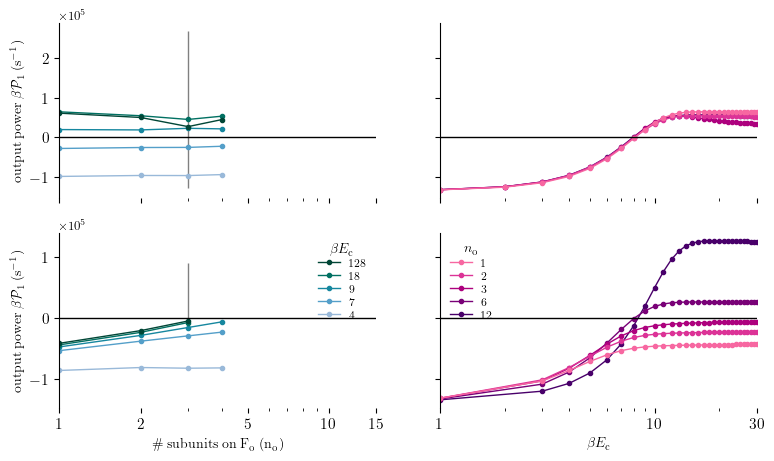

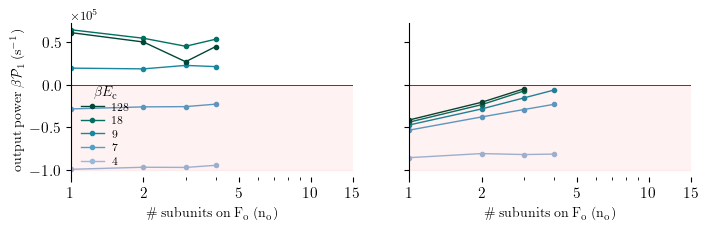

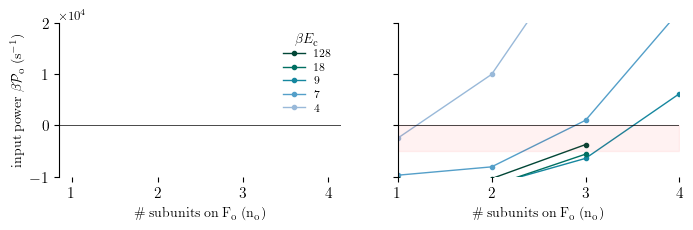

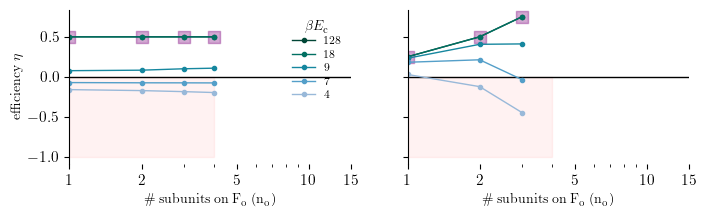

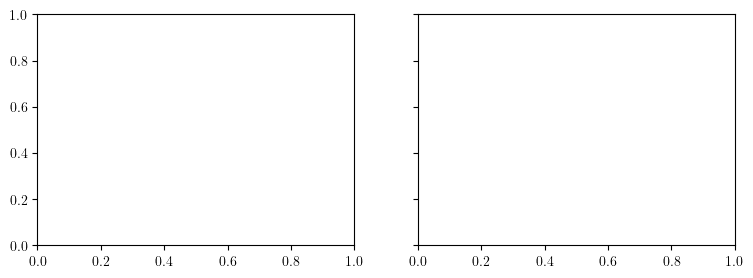

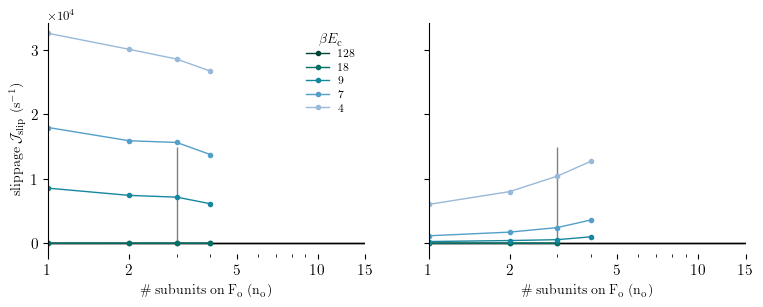

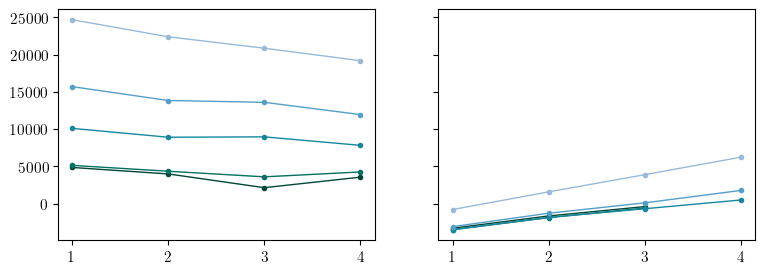

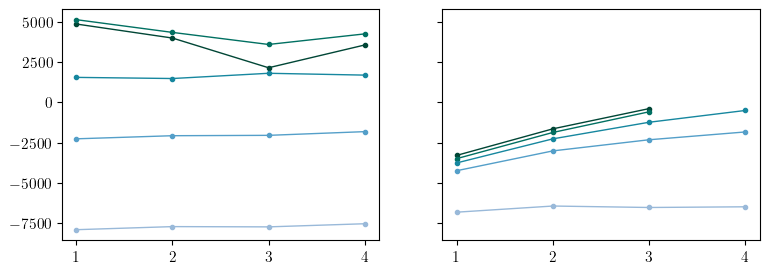

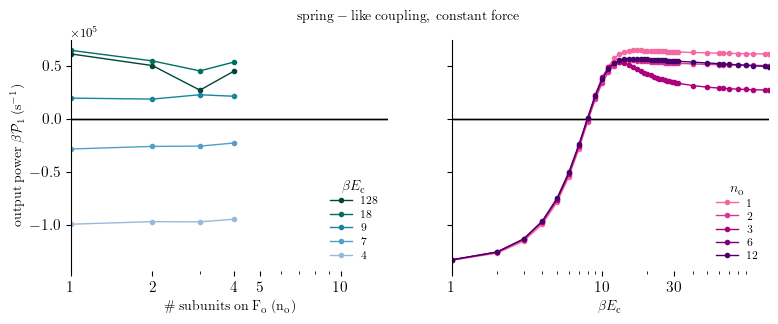

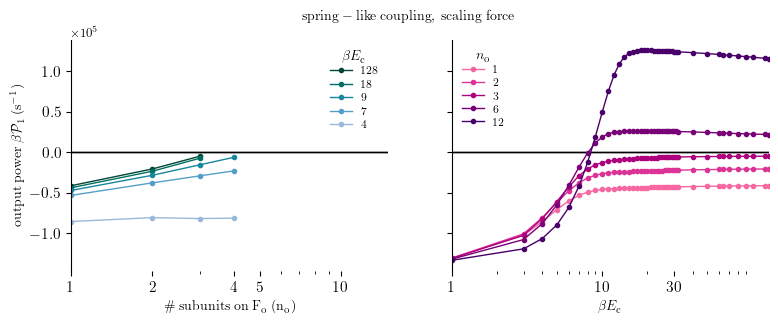

In [85]:
#########first column#######
'''for n1=3 model 1and model 2 use the following'''
target_dir_0 = "/Users/sarealles/Desktop/model1/new_data_540_CM/f0_8/pfe/"
target_dir_0_0 = "/Users/sarealles/Desktop/model1/data_N_1000/pfe/"
target_dir_1_0 = "/Users/sarealles/Desktop/model2/new_data_540_CM/E0_2/f0_4/pfe/"
# 
target_dir_0_0 = "/Users/sarealles/Desktop/Data/Data_processed/pfe_old/"
target_dir_1_0 = "/Users/sarealles/Desktop/Data/Data_processed/pfe_old/"

n0_array_n0_change = [1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0,24.0,25.0,26.0,27.0,28.0,29.0,30.0]
Ec_curve_n0_change = [4.0,7.0,9.0,18.0,128.0] 
Ec_curve_n0_change = [32.0,16.0,8.0,4.0,2.0]
Ec_curve_n0_change = [32.0,8.0,2.0]
Ec_curve_n0_change = [32.0,16.0,8.0,4.0,2.0]
Ec_curve_n0_change = [128.0,18.0,9.0,7.0,4.0]
n0_array_n0_change = [1.0,2.0,3.0,4.0]


#########second column#######
target_dir_0_1 = "/Users/sarealles/Desktop/Data/Data_processed/pfe/"
target_dir_1_1 = "/Users/sarealles/Desktop/Data/Data_processed/pfe_old/"
n0_curve_Ec_change = [1.0,2.0,3.0,6.0,12.0,15.0]
n0_curve_Ec_change = [1.0,2.0,3.0,6.0,12.0]
Ec_array_Ec_change = [1.0,2.0,3.0,6.0,9.0,11.0]
########################
'''first two values for the first column'''
target_dir = [target_dir_0_0,target_dir_1_0, target_dir_0_1,target_dir_1_1]
n1 = 3.0
f0_array = [4.0,4.0,4.0,4.0]
f1_array = [-2.0,-2.0,-2.0,-2.0]
model_array = ["model1","model2","model1","model2"]
#########################

# ##########################
# '''mod3, n1 = 5'''
# # target_dir_0 = "/Users/sarealles/Desktop/model3/n1_5/pfe/"
# target_dir_1 = "/Users/sarealles/Desktop/model4/f0_8/pfe/"
# target_dir_0 = "/Users/sarealles/Desktop/model3/N_1000_f0_8/pfe/"
# target_dir_0 = "/Users/sarealles/Desktop/model3/Thesis/pfe/"
# target_dir_1 = "/Users/sarealles/Desktop/model4/Thesis/pfe/"
# target_dir = [target_dir_0,target_dir_1, target_dir_0,target_dir_1]
# n1 = 3.0
# f0_array = [8.0,8.0,8.0,8.0]
# f1_array = [-2.0,-2.0,-2.0,-2.0]
# model_array = ["model3","model4","model3","model4"]
# model_array = ["model4","model3","model4","model3"]
# ##########################
# '''mod3 and CS'''
# target_dir_0 = "/Users/sarealles/Desktop/model3/Thesis/pfe/"
# # target_dir_0 = "/Users/sarealles/Desktop/model3/n1_5/pfe/"
# target_dir_1 = "/Users/sarealles/Desktop/CS/pfe/"

# target_dir = [target_dir_0,target_dir_1, target_dir_0,target_dir_1]
# n1 = 3.0
# f0_array = [8.0,8.0,8.0,8.0]
# f1_array = [-2.0,-0.0,-2.0,-0.0]
# model_array = ["model3","CS","model3","CS"]
##########################



'''change the params in the function'''
plot_P_vs_n0_and_vs_Ec_two_models(target_dir, model_array,n0_array_n0_change,Ec_curve_n0_change,Ec_array_Ec_change, n0_curve_Ec_change, n1,f0_array,f1_array,dt=0.001,N=1000,drag=1500)

plt.show()  


In [51]:
def plot_P_vs_n0_and_vs_Ec_two_models_BFM(target_dir, model_array,n1_array_n1_change,Ec_curve_n1_change,Ec_array_Ec_change, n1_curve_Ec_change, n0_array,f0_array,f1_array,dt=0.001,N=1000,drag=1000):
    timescale = 1.5 * 10**4 
    '''timescale used in thesis'''
    timescale = 4.8 * 10**7 

    xlim= 15
    #fig for P1  vs n0 (left), P1 vs Ec (right)
    fig, ax = plt.subplots(2, 2, figsize=(9,5),sharey="row",sharex="col")
    #fig1 for P1  vs n0
    fig1, ax1 = plt.subplots(1, 2, figsize=(9,3),sharey="row")
    #fig7 for P0  vs n0
    fig7, ax7 = plt.subplots(1, 2, figsize=(9,3),sharey="row")
    #fig3 for eta vs n0
    fig3, ax3 = plt.subplots(1, 2, figsize=(9,3),sharey="row")
    #fig6 for P1  vs Ec
    fig6, ax6 = plt.subplots(1, 2, figsize=(9,3),sharey="row")
    
    ####Model plots######
    #model 1, fig4 for P1  vs n0, vs Ec
    fig4, ax4 = plt.subplots(1, 2, figsize=(9,3),sharey="row")
    #model 2, fig4 for P1  vs n0, vs Ec
    fig5, ax5 = plt.subplots(1, 2, figsize=(9,3),sharey="row")
    
    if "model1" in model_array and "model2" in model_array:
        fig4.suptitle(r"$\rm{spring-like \ coupling}, \ \rm{constant \ force}$", fontsize=fs)
        fig5.suptitle(r"$\rm{spring-like \ coupling}, \ \rm{scaling \ force}$", fontsize=fs)
    else:
        fig4.suptitle(r"$\rm{gear-like \ coupling}, \ \rm{constant \ force}$", fontsize=fs)
        fig5.suptitle(r"$\rm{gear-like \ coupling}, \ \rm{scaling \ force}$", fontsize=fs)

    
    # ax[0,0].set_title(r"$\mathrm{constant \ force}$", fontsize=24)
    # ax[1,0].set_title(r"$\mathrm{scaling \ force}$", fontsize=24)
    # ax[0,1].set_title(r"$\mathrm{constant \ force}$", fontsize=24)
    # ax[1,1].set_title(r"$\mathrm{scaling \ force}$", fontsize=24)
    
    # ax1[0].set_title(r"$\mathrm{constant \ force}$", fontsize=24)
    # ax1[1].set_title(r"$\mathrm{scaling \ force}$", fontsize=24)
    # ax3[0].set_title(r"$\mathrm{constant \ force}$", fontsize=24)
    # ax3[1].set_title(r"$\mathrm{scaling \ force}$", fontsize=24)

    
    ax[1,0].vlines(5, 0, 0.15*(10**5), colors='grey', linestyles='solid', lw=1.0, alpha=1, zorder=-1000)
    
    y=-1.3*(10**5)*np.ones(30)

    
    ####setting axis limit for models' plots#####
    ax4[0].set_xlim(left=1, right=xlim)
    ax4[1].set_xlim(left=1,right=128)
    ax4[0].set_xticks([1, 2,5, 10, 15])
    ax4[0].get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
    ax5[0].set_xlim(left=1, right=xlim)
    ax5[1].set_xlim(left=1,right=128)
    ax5[0].set_xticks([1, 2,5, 10, 15])
    ax5[0].get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())

    #########
    for i in range(2):
        '''P1 sepaarte'''
        ax1[i].axhline(0.0,color="black", lw=1.0)
        ax1[i].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
        ax1[i].yaxis.offsetText.set_fontsize(off_text_size) 
        ax1[i].spines['right'].set_visible(False)
        ax1[i].spines['bottom'].set_visible(False)
        ax1[i].spines['top'].set_visible(False)
        ax1[i].set_xscale("log")
        ax1[i].set_xlim(left=1,right=xlim)
        ax1[i].set_xticks([1, 2,5, 10,15])
        ax1[i].get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
        
        ax7[i].axhline(0.0, color="black", lw=1.0)
        ax7[i].ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
        ax7[i].yaxis.offsetText.set_fontsize(off_text_size)
        ax7[i].spines['right'].set_visible(False)
        ax7[i].spines['bottom'].set_visible(False)
        ax7[i].spines['top'].set_visible(False)
        ax7[i].set_xscale("log")
        ax7[i].set_xlim(left=1, right=xlim)
        ax7[i].set_xticks([1, 2, 5, 10, 15])
        ax7[i].get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
        '''eta separate'''
        ax3[i].axhline(0.0, color="black", lw=1.0)
        ax3[i].spines['right'].set_visible(False)
        ax3[i].spines['bottom'].set_visible(False)
        ax3[i].spines['top'].set_visible(False)
        ax3[i].set_xscale("log")
        ax3[i].set_xlim(left=1, right=xlim)
        ax3[i].set_xticks([1, 2,5, 10, 15])
        ax3[i].get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
        '''models separate'''
        ax4[i].axhline(0.0,color="black", lw=1.0)
        ax4[i].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
        ax4[i].yaxis.offsetText.set_fontsize(off_text_size) 
        ax4[i].axhline(0.0, color="black", lw=1.0)
        ax4[i].spines['right'].set_visible(False)
        ax4[i].spines['bottom'].set_visible(False)
        ax4[i].spines['top'].set_visible(False)
        ax4[i].set_xscale("log")

        #########
        ax5[i].axhline(0.0,color="black", lw=1.0)
        ax5[i].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
        ax5[i].yaxis.offsetText.set_fontsize(off_text_size) 
        ax5[i].axhline(0.0, color="black", lw=1.0)
        ax5[i].spines['right'].set_visible(False)
        ax5[i].spines['bottom'].set_visible(False)
        ax5[i].spines['top'].set_visible(False)
        ax5[i].set_xscale("log")
        ###########
        ax6[i].axhline(0.0, color="black", lw=1.0)
        ax6[i].ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
        ax6[i].yaxis.offsetText.set_fontsize(off_text_size)
        ax6[i].spines['right'].set_visible(False)
        ax6[i].spines['bottom'].set_visible(False)
        ax6[i].spines['top'].set_visible(False)
        ax6[i].set_xscale("log")

        for j in range(2):
            ax[i,j].axhline(0.0,color="black", lw=1.0)
            ax[i,j].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
            ax[i, j].yaxis.offsetText.set_fontsize(off_text_size) 
            ax[i,j].spines['right'].set_visible(False)
            ax[i,j].spines['bottom'].set_visible(False)
            ax[i,j].spines['top'].set_visible(False)
            ax[i,j].set_xscale("log")
            ax[i,0].set_xlim(left=1,right=xlim)
            ax[0,j].set_xlim(left=1,right=128)
            ax[i,0].set_xticks([1, 2,5, 10,15])
            ax[i,j].get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
            ax6[j].yaxis.offsetText.set_fontsize(off_text_size) 
            ax5[j].yaxis.offsetText.set_fontsize(off_text_size) 
            ax4[j].yaxis.offsetText.set_fontsize(off_text_size)
            
            
            
            

            

            
            
    '''second column'''
    for ii,model in enumerate(model_array[2:]):
        print(ii)
        input_file_name = (
            "/" + model + "_flux_power_efficiency_"
            + "E0_{0}_E1_{1}_psi0_{2}_psi1_{3}_n0_{4}_n1_{5}_phase_{6}_outfile.dat"
            )
        if model == "model1" or model == "model2":
            colors = cm.RdPu(np.linspace(0.5, 1, len(n1_curve_Ec_change)))
        else:
            colors = cm.YlGn(np.linspace(0.5, 1, len(n1_curve_Ec_change)))
            colors = cm.gist_earth(np.linspace(0, 0.8, len(n1_curve_Ec_change)))[::-1]
            

        for h, (n1, color) in enumerate(zip(n1_curve_Ec_change, colors)):
            [
            E0, __,E1, psi_0, psi_1,psi_0_n, psi_1_n, __, __,
            m0, m1, phase,beta, gamma,__
            ] = set_params(model, n0_array[ii+2], n1, f0_array[ii+2], f1_array[ii+2],E0=2.0, E1=2.0)
            n0n1_str = str(int(n0_array[ii+2])) + "_" + str(int(n1))
            target = target_dir[ii+2]
            try:
                Ecouple_array, integrate_flux_X, integrate_flux_Y, integrate_power_X, integrate_power_Y, efficiency, efficiency_mod = loadtxt(
                target + n0n1_str + input_file_name.format(E0, E1, psi_0, psi_1, n0_array[ii+2], n1, phase), unpack=True, usecols=(0, 1, 2, 3, 4, 5, 6))
            except:
                print(f"File not found: {target + n0n1_str + input_file_name.format(E0, E1, psi_0, psi_1, n0_array[ii+2], n1, phase)}")
                continue
            if model=="BFM" or model=="CS":
                ax[ii, 1].plot(
                Ecouple_array, 2*pi*gamma * timescale*(integrate_flux_Y**2), marker="o", lw=1.0, markersize=ms,
                label="${0}$".format(int(n1)), color=color
                )
                if ii == 0:
                    ax4[1].plot(
                    Ecouple_array, gamma * timescale*(integrate_flux_Y**2), marker="o", lw=1.0, markersize=ms,
                    label="${0}$".format(int(n1)), color=color
                    )
                    ax6[0].plot(
                    Ecouple_array, gamma * timescale*(integrate_flux_Y**2), marker="o", lw=1.0, markersize=ms,
                    label="${0}$".format(int(n1)), color=color
                    )
                else:
                    ax5[1].plot(
                    Ecouple_array, gamma * timescale*(integrate_flux_Y**2), marker="o", lw=1.0, markersize=ms,
                    label="${0}$".format(int(n1)), color=color
                    )
                    ax6[1].plot(
                    Ecouple_array, gamma * timescale*(integrate_flux_Y**2), marker="o", lw=1.0, markersize=ms,
                    label="${0}$".format(int(n1)), color=color
                    )
            else:
                print("second column model4")
                ax[ii, 1].plot(
                Ecouple_array, -2 * pi * timescale*integrate_power_Y, marker="o", lw=1.0, markersize=ms,
                label="${0}$".format(int(n1)), color=color, zorder=-h
                )
             
    
    ####################################################
    '''first column'''
    Ecouple= []
    maximizing_n1 = []
    index = -1
    for jj,model in enumerate(model_array[:2]):
        index +=1
        f0 = f0_array[jj]
        f1 = f1_array[jj]
        if model == "model1" or model == "model2":
            colors = cm.PuBuGn(np.linspace(0.4, 1, len(Ec_curve_n1_change)))
        else:
            colors = cm.YlOrBr(np.linspace(0.4, 1, len(Ec_curve_n1_change)))
        colors1 = cm.gist_earth(np.linspace(0, 0.8, len(Ec_curve_n1_change)))[::-1]
        colors1 = cm.YlOrBr(np.linspace(0.4, 1, len(Ec_curve_n1_change)))
        for i,Ec in enumerate(Ec_curve_n1_change):
            n1_exists = []
            P_at_Ec = []
            P0_at_Ec = []
            eta_at_Ec = []
            eta_at_inf = []
            eta_Fo_wins = []
            j1_at_Ec = []
            jo_at_Ec = []
            jslip_at_Ec = []
            
            for n1 in n1_array_n1_change:
                params = set_params(model, n0_array[jj],n1,f0,f1)
                n0n1_str = str(int(n0_array[jj]))+"_"+ str(int(n1))
                '''uncomment the following line and comment the lines after for model1,2'''

                target_dir_temp = target_dir[jj] + n0n1_str
                #     print(target_dir_temp)
                    
                if not os.path.exists(target_dir_temp):
                    print(target_dir_temp)
            
                [
                E0, __,E1, psi_0, psi_1,psi_0_n, psi_1_n, __, __,
                m0, m1, phase,beta, gamma,__
                ] = params

                input_file_name = ("/" + model + "_flux_power_efficiency_"
                + "E0_{0}_E1_{1}_psi0_{2}_psi1_{3}_n0_{4}_n1_{5}_phase_{6}_outfile.dat")
                
                if not os.path.exists(target_dir_temp + input_file_name.format(E0, E1, psi_0, psi_1, n0_array[jj], n1, phase,dt,N)):
                    continue

                Ec_list,integrate_flux_X, integrate_flux_Y,integrate_power_X, integrate_power_Y, efficiency,efficiency_mod= loadtxt(
                target_dir_temp + input_file_name.format(E0,E1, psi_0, psi_1, n0_array[jj],n1,phase,dt,N),unpack=True, usecols=(0,1,2,3,4,5,6))

                # Convert Ec_list to a list if it is a single value
                if isinstance(Ec_list, float):
                    Ec_list = [Ec_list]
                    integrate_power_Y = [integrate_power_Y]
                    integrate_power_X = [integrate_power_X]
                    integrate_flux_X = [integrate_flux_X]
                    integrate_flux_Y = [integrate_flux_Y]
                    efficiency_mod = [efficiency_mod]
                    efficiency = [efficiency]

                # print(integrate_power_Y)
                for j in range(len(Ec_list)):
                    if Ec_list[j] == Ec:
                        j1_at_Ec.append(integrate_flux_Y[j])
                        jo_at_Ec.append(integrate_flux_X[j])
                        eta_Fo_wins.append(efficiency[j])
                        n1_exists.append(int(n1))
                        P0_at_Ec.append(2*pi*integrate_power_X[j])
                        
                        
                        if model=="BFM" and f1==-0.0:
                            P_at_Ec.append(2*pi*drag*((j1_at_Ec[-1])**2))
                            # eta_at_Ec.append(P_at_Ec[-1]/P0_at_Ec[-1])
                        else:
                            P_at_Ec.append(-2*pi*integrate_power_Y[j])
                            eta_at_Ec.append(efficiency_mod[j])
                            
                        
                        if model =="model3" or model=="model4" or model=="BFM":
                            jslip_at_Ec.append(n0_array[jj]*integrate_flux_X[j]-n1*integrate_flux_Y[j])
                        else:
                            jslip_at_Ec.append(integrate_flux_X[j]-integrate_flux_Y[j])
                            
                        
                eta_at_inf.append(infinite_eff(psi_0,psi_1,n0_array[jj],n1,model))
                if model == "model4":
                    print(f"n0 is {n0_array[jj]}, eta_at_inf is {eta_at_inf[-1]}")

            if len(n1_exists)!=0:
                Ecouple.append(Ec)
                maximizing_n1.append(n1_exists[argmax(j1_at_Ec)])
            # print(fr"at {int(Ec)}, n0 that maximizes J1 is: {n0_exists[argmax(j1_at_Ec)]}")
            '''efficiency separate fig'''
            if model == "model1":
                ax3[jj].scatter(n1_array_n1_change,eta_at_inf, marker="s",alpha = 0.08, s=70, color='purple')  
            if model =="model2":
                eta_at_inf[3]=np.nan                    
                ax3[jj].scatter(n1_array_n1_change,eta_at_inf, marker="s",alpha = 0.08, s=70, color='purple')  
                n1_exists_no_stall = []
                eta_at_Ec_no_stall = []
                stall_point = int(-8*f1/f0)
                print("stall point is ", stall_point)
                for ii,n1 in enumerate(n1_exists):
                    if int(n1) != stall_point:
                        eta_at_Ec_no_stall.append(eta_at_Ec[ii])
                        n1_exists_no_stall.append(n1)
                    else:
                        eta_at_Ec_no_stall.append(nan)
                        n1_exists_no_stall.append(nan)
                        
                eta_at_Ec_no_stall = array(eta_at_Ec_no_stall)
                n1_exists_no_stall = array(n1_exists_no_stall)
            elif model =="model4":
                n1_exists_no_stall = []
                eta_at_Ec_no_stall = []
                stall_point = int(-f0*n1/f1)
                for ii,n1 in enumerate(n1_exists):
                    if int(n1) != stall_point:
                        eta_at_Ec_no_stall.append(eta_at_Ec[ii])
                        n1_exists_no_stall.append(n1)
                eta_at_Ec_no_stall = array(eta_at_Ec_no_stall)
                n1_exists_no_stall = array(n1_exists_no_stall)
            else:
                n1_exists_no_stall = n1_exists
                eta_at_Ec_no_stall = eta_at_Ec
            if len(eta_at_Ec)>0:
                ax3[jj].plot(n1_exists_no_stall,eta_at_Ec_no_stall, label = fr"${int(Ec)}$",marker ="o", color=colors[i],lw=1.0,markersize=ms)
            ax3[jj].tick_params(labelsize=ts, axis='both')
            ax3[jj].set_xlabel(r"$\# \ \mathrm{subunits \ on} \ \rm F_{\rm 1} \ (n_{\rm 1})$", fontsize=fs)
            # print("j1 is",  j1_at_Ec)
            #################

            ax[index,0].plot(n1_exists,timescale*array(P_at_Ec), label = fr"${int(Ec)}$",marker ="o", color=colors[i],lw=1.0,markersize=ms)
            if jj == 0:
                ax4[0].plot(n1_exists,timescale*array(P_at_Ec), label = fr"${int(Ec)}$",marker ="o", color=colors[i],lw=1.0,markersize=ms)
            else:
                ax5[0].plot(n1_exists,timescale*array(P_at_Ec), label = fr"${int(Ec)}$",marker ="o", color=colors[i],lw=1.0,markersize=ms)

            ax[index,0].tick_params(labelsize=ts, axis='both')
            ax[index,1].tick_params(labelsize=ts, axis='both')
            ax4[index].tick_params(labelsize=ts, axis='both')
            ax5[index].tick_params(labelsize=ts, axis='both')
            
            ax[index,0].set_xticks(n1_exists)
            # ax4[0].set_xticks(n0_exists)
            # ax5[0].set_xticks(n0_exists)
            ax[index,0].set_ylabel(r"$\mathrm{output \ power} \ \beta \mathcal{P}_{1} \ (\rm{s}^{-1})$", fontsize=fs)
            ax4[0].set_ylabel(r"$\mathrm{output \ power} \ \beta \mathcal{P}_{1} \ (\rm{s}^{-1})$", fontsize=fs)
            ax5[0].set_ylabel(r"$\mathrm{output \ power} \ \beta \mathcal{P}_{1} \ (\rm{s}^{-1})$", fontsize=fs)
            
            
            '''separate fig'''
            ax1[jj].plot(n1_exists,timescale*array(P_at_Ec), label = fr"${int(Ec)}$",marker ="o", color=colors1[i],lw=1.0,markersize=6)
            ax1[jj].tick_params(labelsize=ts, axis='both')
            ax1[jj].tick_params(labelsize=ts, axis='both')
            ax1[jj].set_xticks(n1_exists)
            ax1[0].set_ylabel(r"$\mathrm{output \ power} \ \beta \mathcal{P}_{1} \ (\rm{s}^{-1})$", fontsize=fs)
            
            ax7[jj].plot(n1_exists,timescale*array(P0_at_Ec), label = fr"${int(Ec)}$",marker ="o", color=colors1[i],lw=1.0,markersize=6)
            ax7[jj].tick_params(labelsize=ts, axis='both')
            ax7[jj].tick_params(labelsize=ts, axis='both')
            ax7[jj].set_xticks(n1_exists)
            ax7[0].set_ylabel(r"$\mathrm{input \ power} \ \beta \mathcal{P}_{\rm o} \ (\rm{s}^{-1})$", fontsize=fs)
            ax6[0].set_ylabel(r"$\mathrm{output \ power} \ \beta \mathcal{P}_{1} \ (\rm{s}^{-1})$", fontsize=fs)
            ax6[jj].tick_params(labelsize=ts, axis='both')
            ax6[jj].tick_params(labelsize=ts, axis='both')       
    '''separate fig'''
    ax3[0].set_ylabel(r"$\mathrm{efficiency} \ \eta$", fontsize=fs)
    ax3[0].legend(prop={'size': l_entry_s}, title=r'$\beta E_{\rm c}$', title_fontsize=l_title_s, frameon=False, ncol=1, labelspacing=0.3, loc='best')


    
    ax1[1].set_xlabel(r"$\# \ \mathrm{subunits \ on} \ \rm F_{\rm 1} \ (n_{\rm 1})$", fontsize=fs)
    ax1[0].set_xlabel(r"$\# \ \mathrm{subunits \ on} \ \rm F_{\rm 1} \ (n_{\rm 1})$", fontsize=fs)
    ax1[1].set_xticks(n1_exists)
    ax1[1].set_xticks([1,2,5,10,15])
    ax1[0].set_xticks(n1_exists)
    ax1[0].set_xticks([1,2,5,10,15])
    ax1[1].get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
    ax1[0].get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
    ax1[0].legend(prop={'size': l_entry_s}, title=r'$\beta E_{\rm c}$', title_fontsize=l_title_s, frameon=False, ncol=1, labelspacing=0.3, loc='best')

    ax7[1].set_xlabel(r"$\# \ \mathrm{subunits \ on} \ \rm F_{\rm 1} \ (n_{\rm 1})$", fontsize=fs)
    ax7[0].set_xlabel(r"$\# \ \mathrm{subunits \ on} \ \rm F_{\rm 1} \ (n_{\rm 1})$", fontsize=fs)
    ax7[1].set_xticks(n1_exists)
    ax7[1].set_xticks([1,2,5,10,15])
    ax7[0].set_xticks(n1_exists)
    ax7[0].set_xticks([1,2,5,10,15])
    ax7[1].get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
    ax7[0].get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
    ax7[0].legend(prop={'size': l_entry_s}, title=r'$\beta E_{\rm c}$', title_fontsize=l_title_s, frameon=False, ncol=1, labelspacing=0.3, loc='best')

    '''models'''
    ax4[0].set_xlabel(r"$\# \ \mathrm{subunits \ on} \ \rm{F}_{\rm 1} \ (n_{\rm 1})$", fontsize=fs)
    ax4[1].set_xlabel(r"$\beta E_{\rm c}$", fontsize=fs)
    ax4[0].set_xticks(n1_exists)
    ax4[0].set_xticks([1,2,5,10,int(n1_array_n1_change[-1])])
    ax4[0].get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
    ax4[1].set_xticks([1,10,100])
    ax4[1].get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
    ax4[0].legend(prop={'size': l_entry_s}, title=r'$\beta E_{\rm c}$', title_fontsize=l_title_s, frameon=False, ncol=1, labelspacing=0.3, loc='best')
    ax4[1].legend(prop={'size': l_entry_s}, title=r'$n_{\rm 1}$', title_fontsize=l_title_s, frameon=False, ncol=1, labelspacing=0.25, loc='best')
    
    ax5[0].set_xlabel(r"$\# \ \mathrm{subunits \ on} \ \rm{F}_{\rm 1} \ (n_{\rm 1})$", fontsize=fs)
    ax5[1].set_xlabel(r"$\beta E_{\rm c}$", fontsize=fs)
    ax5[0].set_xticks(n1_exists)
    ax5[0].set_xticks([1,2,5,10,int(n1_array_n1_change[-1])])
    ax5[0].get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
    ax5[1].set_xticks([1,10,100])
    ax5[1].get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
    ax5[0].legend(prop={'size': l_entry_s}, title=r'$\beta E_{\rm c}$', title_fontsize=l_title_s, frameon=False, ncol=1, labelspacing=0.3, loc='best')
    ax5[1].legend(prop={'size': l_entry_s}, title=r'$n_{\rm 1}$', title_fontsize=l_title_s, frameon=False, ncol=1, labelspacing=0.25, loc='best')

    ax6[1].set_xlabel(r"$\beta E_{\rm c}$", fontsize=fs)
    ax6[0].set_xlabel(r"$\beta E_{\rm c}$", fontsize=fs)
    ax6[0].get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
    ax6[1].set_xticks([1,10,100])
    ax6[0].set_xticks([1,10,100])
    ax6[1].get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
    ax6[0].legend(prop={'size': l_entry_s}, title=r'$n_{\rm 1}$', title_fontsize=l_title_s, frameon=False, ncol=1, labelspacing=0.3, loc='best')
    # ax6[1].legend(prop={'size': l_entry_s}, title=r'$n_{\rm 1}$', title_fontsize=l_title_s, frameon=False, ncol=1, labelspacing=0.25, loc='best')
    ###################
    ax[1,0].set_xlabel(r"$\# \ \mathrm{subunits \ on} \ \rm{F}_{\rm 1} \ (n_{\rm 1})$", fontsize=fs)
    ax[1,1].set_xlabel(r"$\beta E_{\rm c}$", fontsize=fs)
    ax[1,0].set_xticks(n1_exists)
    ax[1,0].set_xticks([1,2,5,10,15])
    ax[1,0].get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
    ax[1,0].legend(prop={'size': l_entry_s}, title=r'$\beta E_{\rm c}$', title_fontsize=l_title_s, frameon=False, ncol=1, labelspacing=0.25, loc='best')
    ax[1,1].legend(prop={'size': l_entry_s}, title=r'$n_{\rm 1}$', title_fontsize=l_title_s, frameon=False, ncol=1, labelspacing=0.25, loc='best')


            

    #######################
    
    # ax3[1].fill_between(n0_array,y , where=(y < 0), color='red', alpha=0.2)
    #####################
    # fig.savefig(fr"/Users/sarealles/Desktop/research/Jun25/model1_2_P1_vs_n0_vs_Ec_n1_{n1}_fo_4.pdf",bbox_inches='tight')
    # fig4.savefig(fr"/Users/sarealles/Desktop/research/Thesis_plots/model3_P1_vs_n0_vs_Ec_n1_{n1}_fo_8.pdf",bbox_inches='tight')
    # fig5.savefig(fr"/Users/sarealles/Desktop/research/Thesis_plots/model4_P1_vs_n0_vs_Ec_n1_{n1}_fo_8.pdf",bbox_inches='tight')

    # fig3.savefig(fr"/Users/sarealles/Desktop/research/Paper/model1_2_eta_vs_n0_n1_{n1}_fo_4.pdf",bbox_inches='tight')

    # fig1.savefig(fr"/Users/sarealles/Desktop/research/CM-Aug2025/BFM_P1_vs_n0_n1_{n1}_fo_8_4.pdf",bbox_inches='tight')
    # fig6.savefig(fr"/Users/sarealles/Desktop/research/CM-Aug2025/BFM_P1_vs_Ec_n1_{n1}_fo_8_4.pdf",bbox_inches='tight')

    plt.show()

0
1
/Users/sarealles/Desktop/BFM/BFM_plus/pfe/5_12
/Users/sarealles/Desktop/BFM/BFM_plus/pfe/5_12
/Users/sarealles/Desktop/BFM/BFM_plus/pfe/5_12
/Users/sarealles/Desktop/BFM/BFM_plus/pfe/5_12
/Users/sarealles/Desktop/BFM/BFM_plus/pfe/5_12
/Users/sarealles/Desktop/BFM/change_gamma_f1_0_n1_5/pfe/5_12
/Users/sarealles/Desktop/BFM/change_gamma_f1_0_n1_5/pfe/5_12
/Users/sarealles/Desktop/BFM/change_gamma_f1_0_n1_5/pfe/5_12
/Users/sarealles/Desktop/BFM/change_gamma_f1_0_n1_5/pfe/5_12
/Users/sarealles/Desktop/BFM/change_gamma_f1_0_n1_5/pfe/5_12


/var/folders/9p/vl2cbtm92dv2z3ypp768dkvc0000gn/T/ipykernel_7369/218018290.py:165: UserWarning: loadtxt: input contained no data: "/Users/sarealles/Desktop/BFM/BFM_plus/pfe/5_5/BFM_flux_power_efficiency_E0_2.0_E1_2.0_psi0_8.0_psi1_-0.0_n0_5.0_n1_5.0_phase_0.0_outfile.dat"
  Ecouple_array, integrate_flux_X, integrate_flux_Y, integrate_power_X, integrate_power_Y, efficiency, efficiency_mod = loadtxt(
/var/folders/9p/vl2cbtm92dv2z3ypp768dkvc0000gn/T/ipykernel_7369/218018290.py:165: UserWarning: loadtxt: input contained no data: "/Users/sarealles/Desktop/BFM/BFM_plus/pfe/5_7/BFM_flux_power_efficiency_E0_2.0_E1_2.0_psi0_8.0_psi1_-0.0_n0_5.0_n1_7.0_phase_0.0_outfile.dat"
  Ecouple_array, integrate_flux_X, integrate_flux_Y, integrate_power_X, integrate_power_Y, efficiency, efficiency_mod = loadtxt(
/var/folders/9p/vl2cbtm92dv2z3ypp768dkvc0000gn/T/ipykernel_7369/218018290.py:165: UserWarning: loadtxt: input contained no data: "/Users/sarealles/Desktop/BFM/BFM_plus/pfe/5_16/BFM_flux_power_effici

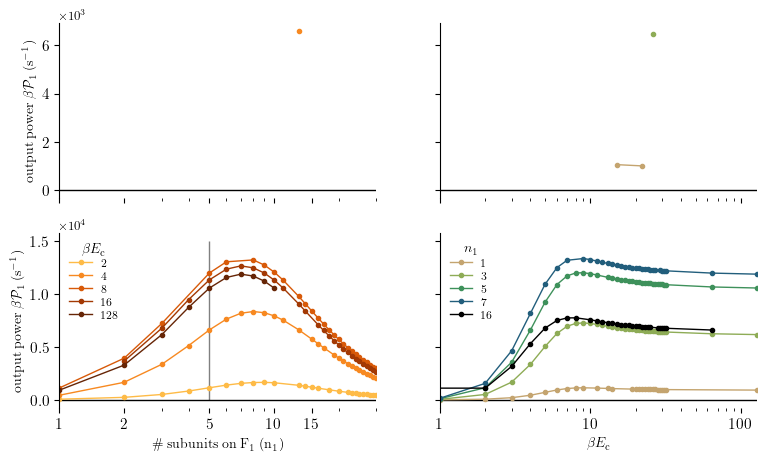

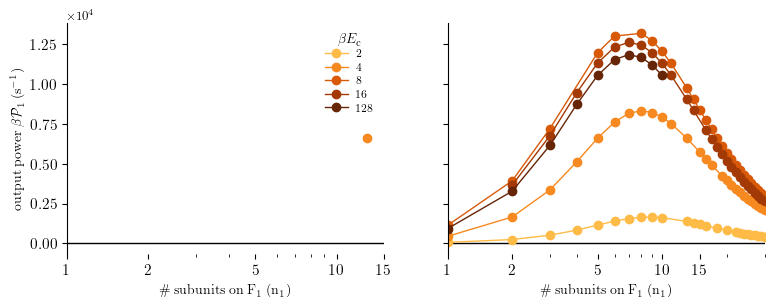

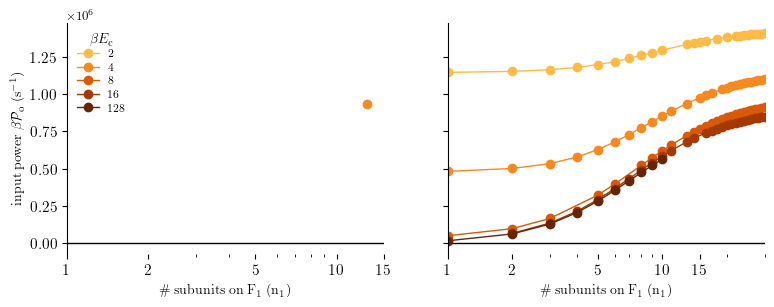

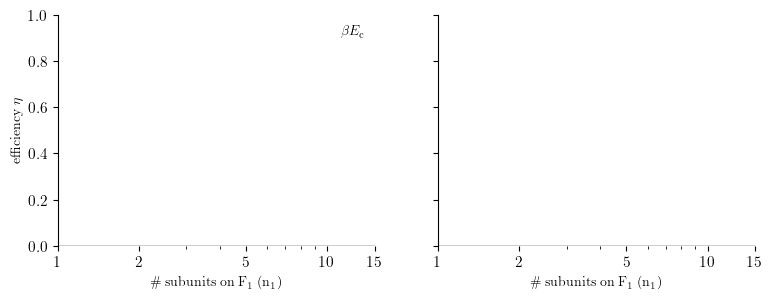

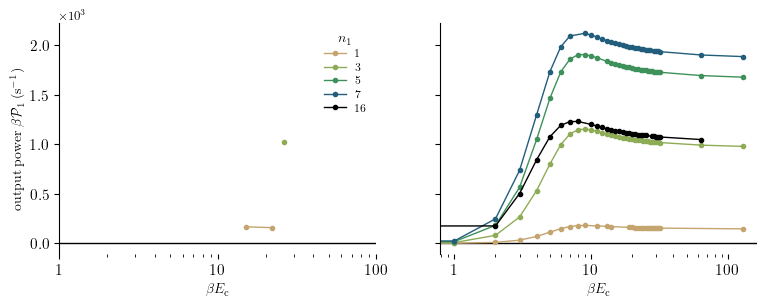

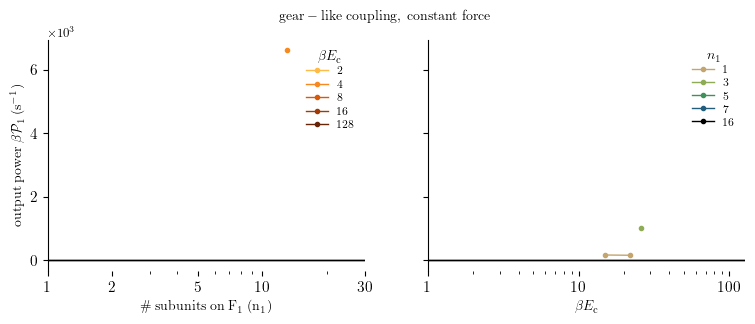

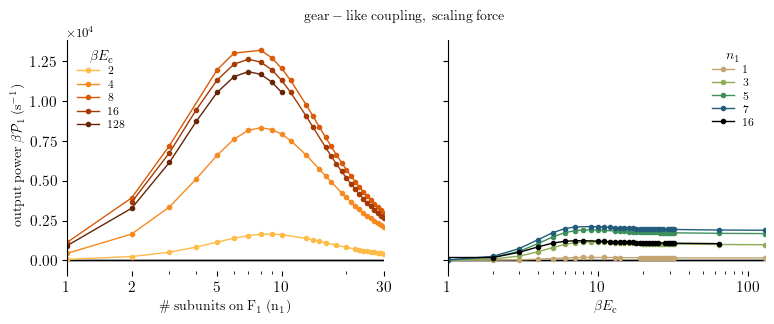

In [ ]:
#########first column#######
n1_array_n1_change = [1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0,24.0,25.0,26.0,27.0,28.0,29.0,30.0]
Ec_curve_n1_change = [2.0,4.0,8.0,16.0,128.0] 
#########second column#######
target_dir_0_1 = "/Users/sarealles/Desktop/Data/Data_processed/pfe/"
target_dir_1_1 = "/Users/sarealles/Desktop/Data/Data_processed/pfe_old/"
n1_curve_Ec_change = [1.0,3.0,5.0,7.0,16.0]
Ec_array_Ec_change = [1.0,2.0,3.0,6.0,9.0,11.0]
###########################
'''BFM'''
'''mod3, n1 = 5'''
target_dir_0 = "/Users/sarealles/Desktop/BFM/change_gamma_f1_0_n1_5/pfe/"
target_dir_1 = "/Users/sarealles/Desktop/BFM/change_gamma_f1_0_n1_5/pfe/"

target_dir = [target_dir_0,target_dir_1, target_dir_0,target_dir_1]
n0 = 5.0
f0_array = [8.0,4.0,8.0,4.0]
f1_array = [-0.0,-0.0,-0.0,-0.0]
model_array = ["BFM","BFM","BFM","BFM"]
###############################
'''BFM and BFM'''

target_dir_0 = "/Users/sarealles/Desktop/BFM/BFM_plus/pfe/"
target_dir_1 = "/Users/sarealles/Desktop/BFM/change_gamma_f1_0_n1_5/pfe/"

target_dir = [target_dir_0,target_dir_1, target_dir_0,target_dir_1]
n0_array = [5.0, 5.0, 5.0, 5.0]
f0_array = [8.0,8.0,8.0,8.0]
f1_array = [-0.0,-0.0,-0.0,-0.0]
model_array = ["BFM","BFM","BFM","BFM"]
#######################

#######################
'''model 4 and BFM'''
# target_dir_0 = "/Users/sarealles/Desktop/model4/n0_8/pfe/"
# target_dir_0 = /Users/sarealles/Desktop/BFM/change_gamma_f1_0/pfe/
# target_dir_1 = "/Users/sarealles/Desktop/BFM/change_gamma_f1_0_n1_5/pfe/"

# target_dir = [target_dir_0,target_dir_1, target_dir_0,target_dir_1]
# n0_array = [8.0, 5.0, 8.0, 5.0]
# f0_array = [4.0,4.0,4.0,4.0]
# f1_array = [-2.0,-0.0,-2.0,-0.0]
# model_array = ["model4","BFM","model4","BFM"]



'''change the params in the function'''
plot_P_vs_n0_and_vs_Ec_two_models_BFM(target_dir, model_array,n1_array_n1_change,Ec_curve_n1_change,Ec_array_Ec_change, n1_curve_Ec_change, n0_array,f0_array,f1_array,dt=0.001,N=1000,drag=1000)

plt.show()  


In [ ]:
pip install qrcode

DEPRECATION: Loading egg at /Users/sarealles/Desktop/Data/code/.venv/lib/python3.12/site-packages/Cython-3.1.0a0-py3.12-macosx-14.0-arm64.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330

[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import qrcode

url = "https://arxiv.org/abs/2508.03869"
img = qrcode.make(url)
img.save("/Users/sarealles/Desktop/research/arxiv_qr.png")

# Thesis: Theroretical background, optimal gearing ratio for tight coupling and barrierless

In [ ]:
from matplotlib.lines import Line2D


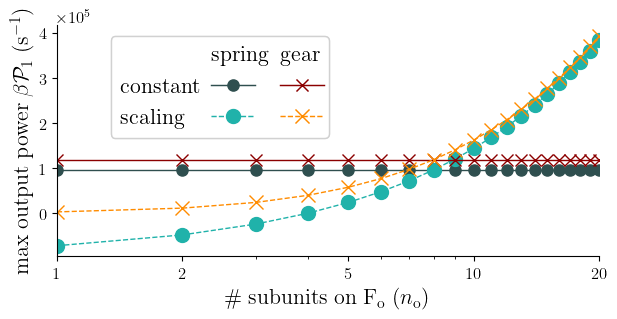

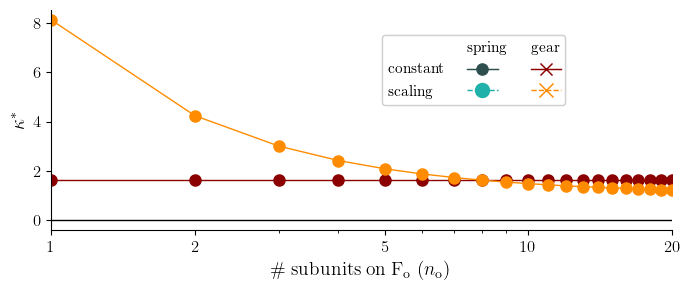

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker
from matplotlib.patches import Rectangle

timescale = 4.8 * 10**7 

def compute_kappa_star(mu_o, mu_1):
    """Compute optimal gearing ratio kappa*."""
    return (-mu_1 + np.sqrt(mu_1**2 + mu_o**2)) / mu_o

def compute_theta_star(mu_o, mu_1, gamma):
    """Compute optimal velocity theta* using kappa*."""
    kappa_star = compute_kappa_star(mu_o, mu_1)
    theta_star = (kappa_star * mu_o + mu_1) / (gamma * (1 + kappa_star**2))
    return theta_star, kappa_star

# --- setup
fig, ax = plt.subplots(figsize=(7,3))
fig1, ax1 = plt.subplots(figsize=(7,3))

mu_o = 4.0
mu_1 = -2.0
gamma = 1000.0
n0_array = np.linspace(1, 20, 20)
color_list = ["purple","darkslategrey","lightseagreen","darkred","darkorange","purple","brown","pink","gray","olive","cyan"]

legend_saver = {}

# --- model 1: spring-like, constant
num=1
h1, = ax.plot(n0_array,
              -timescale*np.ones(20)*mu_1*(mu_o + mu_1)/(2*gamma),
              color=color_list[num], marker="o", lw=1.0, markersize=8, linestyle='solid')
legend_saver['spring_const'] = h1

# --- model 2: spring-like, scaling
num=2
h2, = ax.plot(n0_array,
              -timescale*mu_1*((mu_o*n0_array/8) + mu_1)/(2*gamma),
              color=color_list[num], marker="o", lw=1.0, markersize=10, linestyle='dashed')
legend_saver['spring_scal'] = h2

# --- model 3: gear-like, constant
num=3
theta_const, _ = compute_theta_star(np.array(mu_o*np.ones(20)), mu_1, gamma)
h3, = ax.plot(n0_array,
              -timescale*mu_1*theta_const,
              color=color_list[num], marker="x", lw=1.0, markersize=8, linestyle='solid')
legend_saver['gear_const'] = h3
kappa_star_values = compute_kappa_star(mu_o, mu_1)
ax1.plot(n0_array, kappa_star_values*np.ones(20),
         color=color_list[num], marker="o", lw=1.0, markersize=8, linestyle='solid')

# --- model 4: gear-like, scaling
num=4
theta_scal, _ = compute_theta_star(np.array(mu_o*n0_array/8), mu_1, gamma)
h4, = ax.plot(n0_array,
              -timescale*mu_1*theta_scal,
              color=color_list[num], marker="x", lw=1.0, markersize=10, linestyle='dashed')
legend_saver['gear_scal'] = h4
kappa_star_values = compute_kappa_star(np.array(mu_o * n0_array / 8), mu_1)
ax1.plot(n0_array, kappa_star_values,
         color=color_list[num], marker="o", lw=1.0, markersize=8, linestyle='solid')

# --- formatting ax
# ax.axhline(0.0,color="grey", lw=0.5, zorder=-1000)
ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax.yaxis.offsetText.set_fontsize(12) 
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xscale("log")
ax.set_xlim(left=1,right=20)
ax.set_xticks([1, 2,5, 10,20])
ax.get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax.tick_params(labelsize=12, axis='both')
ax.set_xlabel(r"$\# \ \mathrm{subunits \ on} \ {\rm F}_{\rm o} \ (n_{\rm o})$", fontsize=16)  
ax.set_ylabel(r"$\mathrm{max\ output \ power} \ \beta \mathcal{P}_{1} \ (\rm{s}^{-1})$", fontsize=16)
# ax.fill_between(n0_array, 0, -0.9*(10**5), color='red', alpha=0.05)
# ax.set_ylim(bottom=-0.9*(10**5))

# --- custom 3×3 legend
extra = Rectangle((0, 0), 1, 1, fc="w", fill=False, edgecolor='none', linewidth=0)
legend_handles = [
    extra, extra, extra,                          # row 1: header
    extra, legend_saver['spring_const'], legend_saver['spring_scal'],  # row 2
    extra, legend_saver['gear_const'],   legend_saver['gear_scal'],    # row 3
]
legend_labels = [
    " ", r"$\mathrm{constant}$", r"$\mathrm{scaling}$",
    r"$\mathrm{spring}$", "", "",
    r"$\mathrm{gear}$",   "", "",
]

leg = ax.legend(
    legend_handles, legend_labels,
    loc=9, ncol=3, shadow=False,
    handletextpad=-2, columnspacing=0.5,
    prop={'size': 16},
    bbox_to_anchor=(0.3, 1)
)
ax.add_artist(leg)

# --- formatting ax1
ax1.axhline(0.0, color="black", lw=1.0)
ax1.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
ax1.yaxis.offsetText.set_fontsize(12)
ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)
ax1.set_xscale("log")
ax1.set_xlim(left=1, right=20)
ax1.set_xticks([1, 2, 5, 10, 20])
ax1.get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax1.tick_params(labelsize=12, axis='both')
ax1.set_xlabel(r"$\# \ \mathrm{subunits \ on} \ {\rm F}_{\rm o} \ (n_{\rm o})$", fontsize=14)
ax1.set_ylabel(r"$\kappa^*$", fontsize=14)

# add same legend on ax1 too
leg1 = ax1.legend(
    legend_handles, legend_labels,
    loc=9, ncol=3, shadow=False,
    handletextpad=-2, columnspacing=1.5,
    prop={'size': 11},
    bbox_to_anchor=(0.68, 0.92)
)
ax1.add_artist(leg1)



fig.savefig(f'/Users/sarealles/Desktop/research/Thesis_plots/models_comparison_f0_{mu_o}.pdf', bbox_inches='tight')

plt.tight_layout()
plt.show()

Comapring the models

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker
from matplotlib.patches import Rectangle


def Comparison(n0_array, n1, f0,f1, Ec,target_dir, dt=0.001, N=1000):
    timescale = 4.8 * 10**7 


    # --- setup
    fig, ax = plt.subplots(figsize=(7,3))
    # fig1, ax1 = plt.subplots(figsize=(7,3))


    color_list = ["purple","darkslategrey","lightseagreen","darkred","darkorange","purple","brown","pink","gray","olive","cyan"]

    legend_saver = {}

    # --- model 1: spring-like, constant
    num=1
    n0_exists = []
    P_at_Ec = []
    P0_at_Ec = []
    eta_at_Ec = []
    eta_at_inf = []
    eta_Fo_wins = []
    j1_at_Ec = []
    jo_at_Ec = []
    jslip_at_Ec = []
    for n0 in n0_array:
        params = set_params("model"+f"{num}", n0,n1,f0,f1)
        n0n1_str = str(int(n0))+"_"+ str(int(n1))
        '''uncomment the following line and comment the lines after for model1,2'''

        target_dir_temp = target_dir[num-1] + n0n1_str
        #     print(target_dir_temp)
            
        if not os.path.exists(target_dir_temp):
            print(target_dir_temp)
    
        [
        E0, __,E1, psi_0, psi_1,psi_0_n, psi_1_n, __, __,
        m0, m1, phase,beta, gamma,__
        ] = params

        input_file_name = ("/" + "model"+f"{num}" + "_flux_power_efficiency_"
        + "E0_{0}_E1_{1}_psi0_{2}_psi1_{3}_n0_{4}_n1_{5}_phase_{6}_outfile.dat")
        
        if not os.path.exists(target_dir_temp + input_file_name.format(E0, E1, psi_0, psi_1, n0, n1, phase,dt,N)):
            continue

        Ec_list,integrate_flux_X, integrate_flux_Y,integrate_power_X, integrate_power_Y, efficiency,efficiency_mod= loadtxt(
        target_dir_temp + input_file_name.format(E0,E1, psi_0, psi_1, n0,n1,phase,dt,N),unpack=True, usecols=(0,1,2,3,4,5,6))

        # Convert Ec_list to a list if it is a single value
        if isinstance(Ec_list, float):
            Ec_list = [Ec_list]
            integrate_power_Y = [integrate_power_Y]
            integrate_power_X = [integrate_power_X]
            integrate_flux_X = [integrate_flux_X]
            integrate_flux_Y = [integrate_flux_Y]
            efficiency_mod = [efficiency_mod]
            efficiency = [efficiency]

        # print(integrate_power_Y)
        for j in range(len(Ec_list)):
            if Ec_list[j] == Ec:
                j1_at_Ec.append(integrate_flux_Y[j])
                jo_at_Ec.append(integrate_flux_X[j])
                eta_Fo_wins.append(efficiency[j])
                n0_exists.append(int(n0))
                P0_at_Ec.append(2*pi*integrate_power_X[j])
                P_at_Ec.append(-2*pi*integrate_power_Y[j])

                
                # if model =="model3" or model=="model4" or model=="BFM":
                #     jslip_at_Ec.append(n0*integrate_flux_X[j]-n1*integrate_flux_Y[j])
                # else:
                #     jslip_at_Ec.append(integrate_flux_X[j]-integrate_flux_Y[j])
                    
    
    h1, = ax.plot(n0_exists,
                timescale*array(P_at_Ec),
                color=color_list[num], marker="o", lw=1.0, markersize=8, linestyle='solid')
    legend_saver['spring_const'] = h1

    # --- model 2: spring-like, scaling
    num=2
    n0_exists = []
    P_at_Ec = []
    P0_at_Ec = []
    eta_at_Ec = []
    eta_at_inf = []
    eta_Fo_wins = []
    j1_at_Ec = []
    jo_at_Ec = []
    jslip_at_Ec = []
    for n0 in n0_array:
        params = set_params("model"+f"{num}", n0,n1,f0,f1)
        n0n1_str = str(int(n0))+"_"+ str(int(n1))
        '''uncomment the following line and comment the lines after for model1,2'''

        target_dir_temp = target_dir[num-1] + n0n1_str
        #     print(target_dir_temp)
            
        if not os.path.exists(target_dir_temp):
            print(target_dir_temp)
    
        [
        E0, __,E1, psi_0, psi_1,psi_0_n, psi_1_n, __, __,
        m0, m1, phase,beta, gamma,__
        ] = params

        input_file_name = ("/" + "model"+f"{num}" + "_flux_power_efficiency_"
        + "E0_{0}_E1_{1}_psi0_{2}_psi1_{3}_n0_{4}_n1_{5}_phase_{6}_outfile.dat")
        
        if not os.path.exists(target_dir_temp + input_file_name.format(E0, E1, psi_0, psi_1, n0, n1, phase,dt,N)):
            print("path does not exist:", target_dir_temp + input_file_name.format(E0, E1, psi_0, psi_1, n0, n1, phase,dt,N))
            continue

        Ec_list,integrate_flux_X, integrate_flux_Y,integrate_power_X, integrate_power_Y, efficiency,efficiency_mod= loadtxt(
        target_dir_temp + input_file_name.format(E0,E1, psi_0, psi_1, n0,n1,phase,dt,N),unpack=True, usecols=(0,1,2,3,4,5,6))

        # Convert Ec_list to a list if it is a single value
        if isinstance(Ec_list, float):
            Ec_list = [Ec_list]
            integrate_power_Y = [integrate_power_Y]
            integrate_power_X = [integrate_power_X]
            integrate_flux_X = [integrate_flux_X]
            integrate_flux_Y = [integrate_flux_Y]
            efficiency_mod = [efficiency_mod]
            efficiency = [efficiency]

        # print(integrate_power_Y)
        for j in range(len(Ec_list)):
            if Ec_list[j] == Ec:
                j1_at_Ec.append(integrate_flux_Y[j])
                jo_at_Ec.append(integrate_flux_X[j])
                eta_Fo_wins.append(efficiency[j])
                n0_exists.append(int(n0))
                P0_at_Ec.append(2*pi*integrate_power_X[j])
                P_at_Ec.append(-2*pi*integrate_power_Y[j])
    h2, = ax.plot(n0_exists,
                timescale*array(P_at_Ec),
                color=color_list[num], marker="o", lw=1.0, markersize=10, linestyle='dashed')
    legend_saver['spring_scal'] = h2

    # --- model 3: gear-like, constant
    num=3
    n0_exists = []
    P_at_Ec = []
    P0_at_Ec = []
    eta_at_Ec = []
    eta_at_inf = []
    eta_Fo_wins = []
    j1_at_Ec = []
    jo_at_Ec = []
    jslip_at_Ec = []
    for n0 in n0_array:
        params = set_params("model"+f"{num}", n0,n1,f0,f1)
        n0n1_str = str(int(n0))+"_"+ str(int(n1))
        '''uncomment the following line and comment the lines after for model1,2'''

        target_dir_temp = target_dir[num-1] + n0n1_str
        #     print(target_dir_temp)
            
        if not os.path.exists(target_dir_temp):
            print(target_dir_temp)
    
        [
        E0, __,E1, psi_0, psi_1,psi_0_n, psi_1_n, __, __,
        m0, m1, phase,beta, gamma,__
        ] = params

        input_file_name = ("/" + "model"+f"{num}" + "_flux_power_efficiency_"
        + "E0_{0}_E1_{1}_psi0_{2}_psi1_{3}_n0_{4}_n1_{5}_phase_{6}_outfile.dat")
        
        if not os.path.exists(target_dir_temp + input_file_name.format(E0, E1, psi_0, psi_1, n0, n1, phase,dt,N)):
            continue

        Ec_list,integrate_flux_X, integrate_flux_Y,integrate_power_X, integrate_power_Y, efficiency,efficiency_mod= loadtxt(
        target_dir_temp + input_file_name.format(E0,E1, psi_0, psi_1, n0,n1,phase,dt,N),unpack=True, usecols=(0,1,2,3,4,5,6))

        # Convert Ec_list to a list if it is a single value
        if isinstance(Ec_list, float):
            Ec_list = [Ec_list]
            integrate_power_Y = [integrate_power_Y]
            integrate_power_X = [integrate_power_X]
            integrate_flux_X = [integrate_flux_X]
            integrate_flux_Y = [integrate_flux_Y]
            efficiency_mod = [efficiency_mod]
            efficiency = [efficiency]

        # print(integrate_power_Y)
        for j in range(len(Ec_list)):
            if Ec_list[j] == Ec:
                j1_at_Ec.append(integrate_flux_Y[j])
                jo_at_Ec.append(integrate_flux_X[j])
                eta_Fo_wins.append(efficiency[j])
                n0_exists.append(int(n0))
                P0_at_Ec.append(2*pi*integrate_power_X[j])
                P_at_Ec.append(-2*pi*integrate_power_Y[j])
    h3, = ax.plot(n0_exists,
                timescale*array(P_at_Ec),
                color=color_list[num], marker="x", lw=1.0, markersize=8, linestyle='solid')
    legend_saver['gear_const'] = h3
    kappa_star_values = compute_kappa_star(mu_o, mu_1)
    # ax1.plot(n0_array, kappa_star_values*np.ones(20),color=color_list[num], marker="o", lw=1.0, markersize=8, linestyle='solid')

    # --- model 4: gear-like, scaling
    num=4
    n0_exists = []
    P_at_Ec = []
    P0_at_Ec = []
    eta_at_Ec = []
    eta_at_inf = []
    eta_Fo_wins = []
    j1_at_Ec = []
    jo_at_Ec = []
    jslip_at_Ec = []
    for n0 in n0_array:
        params = set_params("model"+f"{num}", n0,n1,f0,f1)
        n0n1_str = str(int(n0))+"_"+ str(int(n1))
        '''uncomment the following line and comment the lines after for model1,2'''

        target_dir_temp = target_dir[num-1] + n0n1_str
        #     print(target_dir_temp)
            
        if not os.path.exists(target_dir_temp):
            print(target_dir_temp)
    
        [
        E0, __,E1, psi_0, psi_1,psi_0_n, psi_1_n, __, __,
        m0, m1, phase,beta, gamma,__
        ] = params

        input_file_name = ("/" + "model"+f"{num}" + "_flux_power_efficiency_"
        + "E0_{0}_E1_{1}_psi0_{2}_psi1_{3}_n0_{4}_n1_{5}_phase_{6}_outfile.dat")
        
        if not os.path.exists(target_dir_temp + input_file_name.format(E0, E1, psi_0, psi_1, n0, n1, phase,dt,N)):
            continue

        Ec_list,integrate_flux_X, integrate_flux_Y,integrate_power_X, integrate_power_Y, efficiency,efficiency_mod= loadtxt(
        target_dir_temp + input_file_name.format(E0,E1, psi_0, psi_1, n0,n1,phase,dt,N),unpack=True, usecols=(0,1,2,3,4,5,6))

        # Convert Ec_list to a list if it is a single value
        if isinstance(Ec_list, float):
            Ec_list = [Ec_list]
            integrate_power_Y = [integrate_power_Y]
            integrate_power_X = [integrate_power_X]
            integrate_flux_X = [integrate_flux_X]
            integrate_flux_Y = [integrate_flux_Y]
            efficiency_mod = [efficiency_mod]
            efficiency = [efficiency]

        # print(integrate_power_Y)
        for j in range(len(Ec_list)):
            if Ec_list[j] == Ec:
                j1_at_Ec.append(integrate_flux_Y[j])
                jo_at_Ec.append(integrate_flux_X[j])
                eta_Fo_wins.append(efficiency[j])
                n0_exists.append(int(n0))
                P0_at_Ec.append(2*pi*integrate_power_X[j])
                P_at_Ec.append(-2*pi*integrate_power_Y[j])

    h4, = ax.plot(n0_exists,
                timescale*array(P_at_Ec),
                color=color_list[num], marker="x", lw=1.0, markersize=10, linestyle='dashed')
    legend_saver['gear_scal'] = h4
    # ax1.plot(n0_array, kappa_star_values,color=color_list[num], marker="o", lw=1.0, markersize=8, linestyle='solid')

    # --- formatting ax
    # ax.axhline(0.0,color="grey", lw=0.5, zorder=-1000)
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax.yaxis.offsetText.set_fontsize(14) 
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_xscale("log")
    ax.set_xlim(left=1,right=15)
    ax.set_xticks([1, 2,5, 10,15])
    ax.get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
    ax.tick_params(labelsize=14, axis='both')
    ax.set_xlabel(r"$\# \ \mathrm{subunits \ on} \ {\rm F}_{\rm o} \ (n_{\rm o})$", fontsize=18)  
    ax.set_ylabel(r"$\mathrm{output \ power} \ \beta \mathcal{P}_{1} \ (\rm{s}^{-1})$", fontsize=18)
    # ax.fill_between(n0_array, 0, -0.8*(10**5), color='red', alpha=0.05)
    # ax.set_ylim(bottom=-0.8*(10**5))
    ax.hlines(0, xmin=1, xmax=15, color='black', lw=0.2, linestyle='solid', zorder=-1000)

    # --- custom 3×3 legend
    extra = Rectangle((0, 0), 1, 1, fc="w", fill=False, edgecolor='none', linewidth=0)
    legend_handles = [
        extra, extra, extra,                          # row 1: header
        extra, legend_saver['spring_const'], legend_saver['spring_scal'],  # row 2
        extra, legend_saver['gear_const'],   legend_saver['gear_scal'],    # row 3
    ]
    legend_labels = [
        " ", r"$\mathrm{constant}$", r"$\mathrm{scaling}$",
        r"$\mathrm{spring}$", "", "",
        r"$\mathrm{gear}$",   "", "",
    ]

    leg = ax.legend(
        legend_handles, legend_labels,
        loc=9, ncol=3, shadow=False,
        handletextpad=-2, columnspacing=0.5,
        prop={'size': 15},
        bbox_to_anchor=(0.8, 1.1)
    )
    ax.add_artist(leg)

    # --- formatting ax1
    ax1.axhline(0.0, color="black", lw=1.0)
    ax1.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
    ax1.yaxis.offsetText.set_fontsize(12)
    ax1.spines['right'].set_visible(False)
    ax1.spines['top'].set_visible(False)
    ax1.set_xscale("log")
    ax1.set_xlim(left=1, right=20)
    ax1.set_xticks([1, 2, 5, 10, 2])
    ax1.get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
    ax1.tick_params(labelsize=12, axis='both')
    ax1.set_xlabel(r"$\# \ \mathrm{subunits \ on} \ {\rm F}_{\rm o} \ (n_{\rm o})$", fontsize=14)
    ax1.set_ylabel(r"$\kappa^*$", fontsize=14)

    # add same legend on ax1 too
    leg1 = ax1.legend(
        legend_handles, legend_labels,
        loc=9, ncol=3, shadow=False,
        handletextpad=-2, columnspacing=1.5,
        prop={'size': 11},
        bbox_to_anchor=(0.68, 0.92)
    )
    ax1.add_artist(leg1)



    # fig.savefig(f'/Users/sarealles/Desktop/research/Thesis_plots/models_comparison_f0_{mu_o}_Ec_{Ec}_with_barriers.pdf', bbox_inches='tight')

    plt.tight_layout()
    plt.show()

/Users/sarealles/Desktop/model1/new/pfe/1_3
/Users/sarealles/Desktop/model1/new/pfe/2_3
/Users/sarealles/Desktop/model1/new/pfe/3_3
/Users/sarealles/Desktop/model1/new/pfe/4_3
/Users/sarealles/Desktop/model1/new/pfe/5_3
/Users/sarealles/Desktop/model1/new/pfe/6_3
/Users/sarealles/Desktop/model1/new/pfe/7_3
/Users/sarealles/Desktop/model1/new/pfe/8_3
/Users/sarealles/Desktop/model1/new/pfe/9_3
/Users/sarealles/Desktop/model1/new/pfe/10_3
/Users/sarealles/Desktop/model1/new/pfe/11_3
/Users/sarealles/Desktop/model1/new/pfe/12_3
/Users/sarealles/Desktop/model1/new/pfe/13_3
/Users/sarealles/Desktop/model1/new/pfe/14_3
/Users/sarealles/Desktop/model1/new/pfe/15_3
/Users/sarealles/Desktop/model4/Thesis/pfe/12_3


/var/folders/9p/vl2cbtm92dv2z3ypp768dkvc0000gn/T/ipykernel_7369/2390808995.py:122: UserWarning: loadtxt: input contained no data: "/Users/sarealles/Desktop/Data/Data_processed/pfe/6_3/model2_flux_power_efficiency_E0_2.0_E1_2.0_psi0_4.0_psi1_-2.0_n0_6.0_n1_3.0_phase_0.0_outfile.dat"
  Ec_list,integrate_flux_X, integrate_flux_Y,integrate_power_X, integrate_power_Y, efficiency,efficiency_mod= loadtxt(
/var/folders/9p/vl2cbtm92dv2z3ypp768dkvc0000gn/T/ipykernel_7369/2390808995.py:122: UserWarning: loadtxt: input contained no data: "/Users/sarealles/Desktop/Data/Data_processed/pfe/14_3/model2_flux_power_efficiency_E0_2.0_E1_2.0_psi0_4.0_psi1_-2.0_n0_14.0_n1_3.0_phase_0.0_outfile.dat"
  Ec_list,integrate_flux_X, integrate_flux_Y,integrate_power_X, integrate_power_Y, efficiency,efficiency_mod= loadtxt(


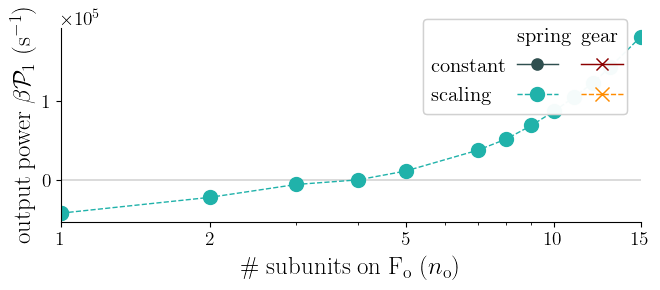

In [ ]:
target_dir=["/Users/sarealles/Desktop/model1/new/pfe/","/Users/sarealles/Desktop/Data/Data_processed/pfe/","/Users/sarealles/Desktop/model3/Thesis/pfe/","/Users/sarealles/Desktop/model4/Thesis/pfe/"]

# def Comparison(n0_array, n1, f0,f1, Ec,target_dir, dt=0.001, N=1000):


'''try these for model2 directory location: /Users/sarealles/Desktop/Data/Data_processed/pfe/ ,/Users/sarealles/Desktop/model2/Paper/pfe/,    /Users/sarealles/Desktop/model2/new_data_540_CM/E0_2/f0_8/pfe'''
n0_array= [1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0]

Comparison(n0_array, n1=3.0, f0=4.0,f1=-2.0, Ec=32.0, target_dir=target_dir, dt=0.001, N=1000)